<a href="https://colab.research.google.com/github/sadia1120/heart-disease-multidataset-framework/blob/main/heart_disease_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###***Toward a Robust and Interpretable Multi-Dataset Framework for Heart Disease Prediction***
via Unified Feature Harmonization and Cross-Dataset Validation
Runtime: Google Colab (CPU is fine; GPU not required)

Pipeline (fixed order — do not reorder): Feature Harmonization → Missing Value Handling → Target Transformation → Dataset Splitting → Feature Scaling

Datasets

Source	Samples	Link
Cleveland	303	https://archive.ics.uci.edu/dataset/45/heart+disease

Statlog	270	https://archive.ics.uci.edu/dataset/145/statlog+heart

Kaggle (1035-sample)	1035	https://www.kaggle.com/datasets/snmahsa/heart-disease

9 Models: CatBoost, LightGBM, SVM, Gradient Boosting, Voting Ensemble, Logistic Regression, Random Forest, XGBoost, Neural Network (MLP)

Contributions mapped to code sections:

Multi-Dataset Integration → Sections 2–5
Unified Feature Harmonization → Section 6
Independent Validation (No Merging) → Section 14
SHAP + LIME Explainability → Section 17
Cross-Dataset XAI Stability Analysis → Section 18
Run cells top to bottom, in order. Each section is labeled to match your flowchart.

#1. Install & Import Libraries

In [ ]:
# Install libraries not preinstalled on Colab
!pip install -q catboost lightgbm shap lime kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [ ]:
import os, io, warnings, json, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directory (change if you mount Google Drive instead)
OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
print("Setup complete.")


Setup complete.


#2. Load Dataset 1 — Cleveland (303 samples)
UCI source, standard 14-column processed file. Missing values are coded as ?.

In [ ]:
CLEVELAND_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

col_names_raw = ["age","sex","cp","trestbps","chol","fbs","restecg",
                  "thalach","exang","oldpeak","slope","ca","thal","target"]

cleveland_raw = pd.read_csv(CLEVELAND_URL, header=None, names=col_names_raw, na_values="?")
print("Cleveland raw shape:", cleveland_raw.shape)
cleveland_raw.head()

Cleveland raw shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


#3. Load Dataset 2 — Statlog (270 samples)
UCI source, space-separated .dat file, same 13 predictors. Target is coded 1 (absence) / 2 (presence) — this raw coding is kept as-is for now; it is standardized in the Target Transformation step later, not here.

In [ ]:
STATLOG_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/heart/heart.dat"

statlog_raw = pd.read_csv(STATLOG_URL, sep=r"\s+", header=None, names=col_names_raw)
print("Statlog raw shape:", statlog_raw.shape)
statlog_raw.head()

Statlog raw shape: (270, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


#4. Load Dataset 3 — Kaggle Heart Disease Dataset (1035 samples)
snmahsa/heart-disease on Kaggle. Two ways to load it — use whichever works for you.

Option A — kagglehub (needs your Kaggle API credentials). Get kaggle.json from https://www.kaggle.com/settings → API → "Create New Token", then run the upload cell first.

Option B — manual upload. If you already have the CSV downloaded, just upload it directly and skip to Option B's cell.

In [ ]:
# --- Option A: kagglehub (run this cell OR Option B, not both) ---
from google.colab import files

# Upload kaggle.json when prompted
uploaded = files.upload()  # select kaggle.json
os.makedirs("/root/.kaggle", exist_ok=True)
for fname in uploaded:
    if fname == "kaggle.json":
        with open("/root/.kaggle/kaggle.json", "wb") as f:
            f.write(uploaded[fname])
        os.chmod("/root/.kaggle/kaggle.json", 0o600)

import kagglehub
kaggle_path = kagglehub.dataset_download("snmahsa/heart-disease")
print("Downloaded to:", kaggle_path)

# Locate the CSV file inside the downloaded folder
csv_files = [f for f in os.listdir(kaggle_path) if f.endswith(".csv")]
print("CSV files found:", csv_files)
kaggle_raw = pd.read_csv(os.path.join(kaggle_path, csv_files[0]))
print("Kaggle raw shape:", kaggle_raw.shape)
kaggle_raw.head()


100%|██████████| 8.84k/8.84k [00:00<00:00, 5.66MB/s]

Extracting files...
Downloaded to: /root/.cache/kagglehub/datasets/snmahsa/heart-disease/versions/4
CSV files found: ['heartv1.csv']
Kaggle raw shape: (1035, 16)


,sex,age,cp,resting_BP,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Max Heart Rate Reserve,Heart Disease Risk Score,target
0,male,65,0,130,254,0,0,147,0,1.4,1,1,3,10,11.44,0
1,male,53,0,140,261,0,0,186,1,0.0,2,0,2,-17,13.51,1
2,male,50,0,122,222,0,0,186,0,0.0,2,0,2,-14,9.46,1
3,female,47,1,112,160,0,1,138,0,0.0,1,0,2,37,8.34,1
4,male,47,0,142,309,0,0,147,1,0.0,1,3,3,28,13.43,0


In [ ]:
# --- Option B: manual upload (use this instead of Option A if you already have the CSV) ---
from google.colab import files
uploaded = files.upload()  # select the Kaggle heart-disease CSV
fname = list(uploaded.keys())[0]
kaggle_raw = pd.read_csv(io.BytesIO(uploaded[fname]))
print("Kaggle raw shape:", kaggle_raw.shape)
kaggle_raw.head()


Saving heartv1.csv to heartv1.csv
Kaggle raw shape: (1035, 16)


,sex,age,cp,resting_BP,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Max Heart Rate Reserve,Heart Disease Risk Score,target
0,male,65,0,130,254,0,0,147,0,1.4,1,1,3,10,11.44,0
1,male,53,0,140,261,0,0,186,1,0.0,2,0,2,-17,13.51,1
2,male,50,0,122,222,0,0,186,0,0.0,2,0,2,-14,9.46,1
3,female,47,1,112,160,0,1,138,0,0.0,1,0,2,37,8.34,1
4,male,47,0,142,309,0,0,147,1,0.0,1,3,3,28,13.43,0


In [ ]:
# IMPORTANT: inspect the actual Kaggle columns before harmonizing —
# rename mapping in Section 6 must match these exact column names.
print(list(kaggle_raw.columns))
kaggle_raw.dtypes

['sex', 'age', 'cp', 'resting_BP', 'chol', 'fbs', 'restecg', 'thalach ', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'Max Heart Rate Reserve', 'Heart Disease Risk Score', 'target']


,0
sex,object
age,int64
cp,int64
resting_BP,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


#5. Feature Harmonization — Core Contribution
Maps all three sources onto one unified schema so a model trained on one dataset can be tested on another. This step only unifies column names / units / encodings — it does not touch missing values or the target label coding. Those are handled in the next two steps, per the fixed pipeline order.

Unified schema (standard 13 clinical predictors + target + source tag):

age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target, source

In [ ]:
UNIFIED_COLUMNS = ["age","sex","cp","trestbps","chol","fbs","restecg",
                    "thalach","exang","oldpeak","slope","ca","thal","target"]

def harmonize_dataset(df, rename_map, source_name):
    # Rename columns to the unified schema, keep only unified columns,
    # enforce numeric dtype, and tag the source.
    d = df.rename(columns=rename_map).copy()
    missing_cols = [c for c in UNIFIED_COLUMNS if c not in d.columns]
    if missing_cols:
        raise ValueError(f"[{source_name}] missing expected columns after rename: {missing_cols}")
    d = d[UNIFIED_COLUMNS].copy()
    for c in UNIFIED_COLUMNS:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d["source"] = source_name
    return d

# Cleveland: already matches the unified schema 1:1
cleveland_map = {c: c for c in col_names_raw}

# Statlog: already matches the unified schema 1:1 (same 13-attribute UCI convention)
statlog_map = {c: c for c in col_names_raw}

# Kaggle: EDIT this mapping if Section 4's printed column list uses different names.
# Left side = column name actually present in kaggle_raw; right side = unified name.
# Clean up column names first (strip hidden whitespace/case issues)
kaggle_raw.columns = kaggle_raw.columns.str.strip()

# Convert sex from text to numeric (male=1, female=0) to match Cleveland/Statlog convention
# Convert sex from text to numeric (male=1, female=0) — only if still text
if kaggle_raw["sex"].dtype == object:
    kaggle_raw["sex"] = kaggle_raw["sex"].map({"male": 1, "female": 0})

# Kaggle: actual column names differ from Cleveland/Statlog naming
kaggle_map = {
    "age": "age", "sex": "sex", "cp": "cp", "resting_BP": "trestbps",
    "chol": "chol", "fbs": "fbs", "restecg": "restecg", "thalach": "thalach",
    "exang": "exang", "oldpeak": "oldpeak", "slope": "slope", "ca": "ca",
    "thal": "thal", "target": "target",
}

cleveland_h = harmonize_dataset(cleveland_raw, cleveland_map, "Cleveland")
statlog_h   = harmonize_dataset(statlog_raw, statlog_map, "Statlog")
kaggle_h    = harmonize_dataset(kaggle_raw, kaggle_map, "Kaggle")

print("Harmonized shapes:")
print("Cleveland:", cleveland_h.shape)
print("Statlog  :", statlog_h.shape)
print("Kaggle   :", kaggle_h.shape)

harmonized = {"Cleveland": cleveland_h, "Statlog": statlog_h, "Kaggle": kaggle_h}
pd.concat(harmonized.values()).groupby("source").head(2)


Harmonized shapes:
Cleveland: (303, 15)
Statlog  : (270, 15)
Kaggle   : (1035, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2,Statlog
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1,Statlog
0,65.0,1.0,0.0,130.0,254.0,0.0,0.0,147.0,0.0,1.4,1.0,1.0,3.0,0,Kaggle
1,53.0,1.0,0.0,140.0,261.0,0.0,0.0,186.0,1.0,0.0,2.0,0.0,2.0,1,Kaggle


In [ ]:
print(kaggle_h["sex"].isna().sum())

0


#6. Missing Value Handling
Applied per source independently (each dataset keeps its own distribution — no cross-source leakage). ca and thal carry almost all the missingness in Cleveland/Statlog-style data; median imputation is used for continuous fields and mode imputation for categorical/coded fields.

In [ ]:
CATEGORICAL_COLS = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
CONTINUOUS_COLS  = ["age","trestbps","chol","thalach","oldpeak"]

def handle_missing(df):
    d = df.copy()
    print(f"[{d['source'].iloc[0]}] missing values before imputation:")
    print(d[UNIFIED_COLUMNS].isna().sum()[lambda s: s > 0])
    for c in CONTINUOUS_COLS:
        d[c] = d[c].fillna(d[c].median())
    for c in CATEGORICAL_COLS:
        d[c] = d[c].fillna(d[c].mode()[0])
    return d

cleveland_c = handle_missing(cleveland_h)
statlog_c   = handle_missing(statlog_h)
kaggle_c    = handle_missing(kaggle_h)

cleaned = {"Cleveland": cleveland_c, "Statlog": statlog_c, "Kaggle": kaggle_c}
print("\nRemaining NaNs per source:",
      {k: int(v[UNIFIED_COLUMNS].isna().sum().sum()) for k, v in cleaned.items()})

[Cleveland] missing values before imputation:
ca      4
thal    2
dtype: int64
[Statlog] missing values before imputation:
Series([], dtype: int64)
[Kaggle] missing values before imputation:
Series([], dtype: int64)

Remaining NaNs per source: {'Cleveland': 0, 'Statlog': 0, 'Kaggle': 0}


#7. Target Transformation
Standardizes the label across sources into a single binary target: 0 = no heart disease, 1 = heart disease.

Cleveland / Kaggle: raw target is 0 (no disease) vs 1–4 (increasing severity) → collapse to 0/1.
Statlog: raw target is 1 (absence) / 2 (presence) → remap to 0/1.

In [ ]:
def transform_target(df, source_name):
    d = df.copy()
    if source_name == "Statlog":
        d["target"] = d["target"].map({1: 0, 2: 1})
    elif source_name == "Kaggle":
        d["target"] = (d["target"] > 0).astype(int)
        d["target"] = 1 - d["target"]   # fix inverted labels confirmed by diagnostic
    else:
        d["target"] = (d["target"] > 0).astype(int)
    return d

cleveland_t = transform_target(cleveland_c, "Cleveland")
statlog_t   = transform_target(statlog_c, "Statlog")
kaggle_t    = transform_target(kaggle_c, "Kaggle")

data_final = {"Cleveland": cleveland_t, "Statlog": statlog_t, "Kaggle": kaggle_t}

print("Class distribution per source (0 = no disease, 1 = disease):")
for name, df in data_final.items():
    print(f"\n{name} (n={len(df)}):")
    print(df["target"].value_counts().sort_index())

Class distribution per source (0 = no disease, 1 = disease):

Cleveland (n=303):
target
0    164
1    139
Name: count, dtype: int64

Statlog (n=270):
target
0    150
1    120
Name: count, dtype: int64

Kaggle (n=1035):
target
0    531
1    504
Name: count, dtype: int64


In [ ]:
# Diagnostic: check if key clinical features associate with target in the SAME direction across sources.
# If the direction flips for Kaggle, its target labels are likely inverted relative to Cleveland/Statlog.
check_features = ["exang", "oldpeak", "cp", "thalach"]

for name, df in data_final.items():
    print(f"\n=== {name} — mean feature value by target class ===")
    print(df.groupby("target")[check_features].mean())


=== Cleveland — mean feature value by target class ===
           exang   oldpeak        cp     thalach
target                                          
0       0.140244  0.586585  2.792683  158.378049
1       0.546763  1.574101  3.589928  139.258993

=== Statlog — mean feature value by target class ===
           exang   oldpeak        cp     thalach
target                                          
0       0.153333  0.622667  2.820000  158.333333
1       0.550000  1.584167  3.616667  138.858333

=== Kaggle — mean feature value by target class ===
           exang   oldpeak        cp     thalach
target                                          
0       0.141243  0.586629  1.376648  158.630885
1       0.545635  1.597619  0.490079  139.228175


#Demographic Table Code

In [ ]:
demographic_rows = []
for source_name in ["Cleveland", "Statlog", "Kaggle"]:
    df = data_final[source_name]
    male_pct = (df["sex"] == 1).mean() * 100
    row = {
        "Source": source_name,
        "N": len(df),
        "Age (mean ± SD)": f"{df['age'].mean():.1f} ± {df['age'].std():.1f}",
        "Age Range": f"{int(df['age'].min())}–{int(df['age'].max())}",
        "Male %": f"{male_pct:.1f}%",
        "Disease Prevalence %": f"{(df['target']==1).mean()*100:.1f}%",
    }
    demographic_rows.append(row)

demographic_df = pd.DataFrame(demographic_rows)
demographic_df.to_csv(os.path.join(OUT_DIR, "table_demographic_summary.csv"), index=False)
demographic_df

,Source,N,Age (mean ± SD),Age Range,Male %,Disease Prevalence %
0,Cleveland,303,54.4 ± 9.0,29–77,68.0%,45.9%
1,Statlog,270,54.4 ± 9.1,29–77,67.8%,44.4%
2,Kaggle,1035,56.4 ± 9.1,28–79,69.4%,48.7%


#8. Class Balance Check — No Resampling Applied
Per your flowchart: all three sources fall within a 46–54% class split, so no SMOTE / undersampling / class-weighting is applied. This cell just verifies that assumption numerically.

In [ ]:
for name, df in data_final.items():
    counts = df["target"].value_counts(normalize=True).sort_index() * 100
    print(f"{name}: no-disease={counts[0]:.1f}%  disease={counts[1]:.1f}%")

Cleveland: no-disease=54.1%  disease=45.9%
Statlog: no-disease=55.6%  disease=44.4%
Kaggle: no-disease=51.3%  disease=48.7%


#9. Dataset Splitting
Stratified 70/15/15 train/validation/test split, computed independently per source (this is what keeps Contribution #3 — "Independent Validation, No Merging" — true throughout the rest of the notebook).

In [ ]:
def split_source(df, source_name, test_size=0.15, val_size=0.15, seed=RANDOM_STATE):
    X = df[UNIFIED_COLUMNS[:-1]]  # exclude target
    y = df["target"]
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size), stratify=y, random_state=seed)
    rel_test = test_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=rel_test, stratify=y_temp, random_state=seed)
    print(f"{source_name}: train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")
    return {"X_train": X_train, "y_train": y_train,
            "X_val": X_val, "y_val": y_val,
            "X_test": X_test, "y_test": y_test}

splits = {name: split_source(df, name) for name, df in data_final.items()}

Cleveland: train=212  val=45  test=46
Statlog: train=189  val=40  test=41
Kaggle: train=724  val=155  test=156


#10. Feature Scaling
StandardScaler fit only on each source's training split (last step in the fixed pipeline, applied after splitting to avoid data leakage). The fitted scaler is kept per source — it is reused as-is in the cross-dataset experiments (Section 15), so that a model always sees features scaled the same way it was trained on.

In [ ]:
scalers = {}
scaled = {}

for name, s in splits.items():
    scaler = StandardScaler().fit(s["X_train"])
    scalers[name] = scaler
    scaled[name] = {
        "X_train": pd.DataFrame(scaler.transform(s["X_train"]), columns=UNIFIED_COLUMNS[:-1], index=s["X_train"].index),
        "X_val":   pd.DataFrame(scaler.transform(s["X_val"]),   columns=UNIFIED_COLUMNS[:-1], index=s["X_val"].index),
        "X_test":  pd.DataFrame(scaler.transform(s["X_test"]),  columns=UNIFIED_COLUMNS[:-1], index=s["X_test"].index),
        "y_train": s["y_train"], "y_val": s["y_val"], "y_test": s["y_test"],
    }

print("Scaling complete for:", list(scaled.keys()))


Scaling complete for: ['Cleveland', 'Statlog', 'Kaggle']


#11. Model Development — 9 Models
CatBoost, LightGBM, SVM, Gradient Boosting, Voting Ensemble, Logistic Regression, Random Forest, XGBoost, Neural Network (MLP).

get_models() returns fresh, unfitted instances every time it's called — this matters because the same model set is reused across many independent train/test runs (independent validation + 6 cross-dataset experiments), and reusing an already-fitted estimator across runs would silently leak information between experiments.

In [ ]:
def get_models(seed=RANDOM_STATE):
    log_reg = LogisticRegression(max_iter=2000, random_state=seed)
    rf      = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=seed)
    xgb     = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             eval_metric="logloss", random_state=seed, verbosity=0)
    cat     = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                                  random_state=seed, verbose=False)
    lgbm    = LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                              random_state=seed, verbose=-1)
    gb      = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                          learning_rate=0.05, random_state=seed)
    svm     = SVC(kernel="rbf", C=1.0, probability=True, random_state=seed)
    mlp     = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000,
                             early_stopping=True, random_state=seed)

    voting  = VotingClassifier(
        estimators=[("lr", LogisticRegression(max_iter=2000, random_state=seed)),
                     ("rf", RandomForestClassifier(n_estimators=300, max_depth=6, random_state=seed)),
                     ("xgb", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                            eval_metric="logloss", random_state=seed, verbosity=0))],
        voting="soft")

    return {
        "Logistic Regression": log_reg,
        "Random Forest": rf,
        "XGBoost": xgb,
        "CatBoost": cat,
        "LightGBM": lgbm,
        "Gradient Boosting": gb,
        "SVM": svm,
        "Neural Network (MLP)": mlp,
        "Voting Ensemble": voting,
    }

MODEL_NAMES = list(get_models().keys())
print(f"{len(MODEL_NAMES)} models registered:")
for m in MODEL_NAMES:
    print(" -", m)


9 models registered:
 - Logistic Regression
 - Random Forest
 - XGBoost
 - CatBoost
 - LightGBM
 - Gradient Boosting
 - SVM
 - Neural Network (MLP)
 - Voting Ensemble


#12. Evaluation Utility
One shared function computes all five metrics (Accuracy, Precision, Recall, F1, ROC-AUC) consistently, whether the run is an independent-validation run or a cross-dataset run.

In [ ]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    return {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    }, model

#13. Independent Validation — Core Contribution (No Merging)
Each of the 9 models is trained and tested within its own source only — train split and test split both come from the same dataset. Datasets are never merged. This is the baseline against which the cross-dataset experiments in Section 15 are compared.

In [ ]:
independent_results = []
fitted_independent_models = {}  # {(source, model_name): fitted model}

for source_name, d in scaled.items():
    models = get_models()
    for model_name, model in models.items():
        metrics, fitted = train_and_evaluate(
            model, d["X_train"], d["y_train"], d["X_test"], d["y_test"])
        metrics.update({"Source": source_name, "Model": model_name})
        independent_results.append(metrics)
        fitted_independent_models[(source_name, model_name)] = fitted
        print(f"[Independent] {source_name:<10s} | {model_name:<22s} "
              f"Acc={metrics['Accuracy']:.3f}  F1={metrics['F1']:.3f}  AUC={metrics['ROC-AUC']:.3f}")

independent_df = pd.DataFrame(independent_results)[
    ["Source", "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
independent_df.to_csv(os.path.join(OUT_DIR, "independent_validation_results.csv"), index=False)
independent_df.sort_values(["Source", "F1"], ascending=[True, False])


[Independent] Cleveland  | Logistic Regression    Acc=0.870  F1=0.864  AUC=0.937
[Independent] Cleveland  | Random Forest          Acc=0.870  F1=0.864  AUC=0.943
[Independent] Cleveland  | XGBoost                Acc=0.826  F1=0.800  AUC=0.920
[Independent] Cleveland  | CatBoost               Acc=0.870  F1=0.864  AUC=0.924
[Independent] Cleveland  | LightGBM               Acc=0.826  F1=0.810  AUC=0.914
[Independent] Cleveland  | Gradient Boosting      Acc=0.826  F1=0.810  AUC=0.920
[Independent] Cleveland  | SVM                    Acc=0.826  F1=0.818  AUC=0.930
[Independent] Cleveland  | Neural Network (MLP)   Acc=0.848  F1=0.844  AUC=0.960
[Independent] Cleveland  | Voting Ensemble        Acc=0.870  F1=0.864  AUC=0.937
[Independent] Statlog    | Logistic Regression    Acc=0.878  F1=0.865  AUC=0.899
[Independent] Statlog    | Random Forest          Acc=0.878  F1=0.857  AUC=0.867
[Independent] Statlog    | XGBoost                Acc=0.829  F1=0.811  AUC=0.853
[Independent] Statlog    | C

,Source,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Cleveland,Logistic Regression,0.869565,0.826087,0.904762,0.863636,0.937143
1,Cleveland,Random Forest,0.869565,0.826087,0.904762,0.863636,0.942857
3,Cleveland,CatBoost,0.869565,0.826087,0.904762,0.863636,0.923810
8,Cleveland,Voting Ensemble,0.869565,0.826087,0.904762,0.863636,0.937143
7,Cleveland,Neural Network (MLP),0.847826,0.791667,0.904762,0.844444,0.960000
6,Cleveland,SVM,0.826087,0.782609,0.857143,0.818182,0.929524
4,Cleveland,LightGBM,0.826087,0.809524,0.809524,0.809524,0.914286
5,Cleveland,Gradient Boosting,0.826087,0.809524,0.809524,0.809524,0.920000
2,Cleveland,XGBoost,0.826087,0.842105,0.761905,0.800000,0.920000
21,Kaggle,CatBoost,0.987179,1.000000,0.973684,0.986667,0.984868


In [ ]:
# Best model per source, by F1
independent_df.loc[independent_df.groupby("Source")["F1"].idxmax()][
    ["Source", "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]

,Source,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Cleveland,Logistic Regression,0.869565,0.826087,0.904762,0.863636,0.937143
21,Kaggle,CatBoost,0.987179,1.000000,0.973684,0.986667,0.984868
9,Statlog,Logistic Regression,0.878049,0.842105,0.888889,0.864865,0.898551


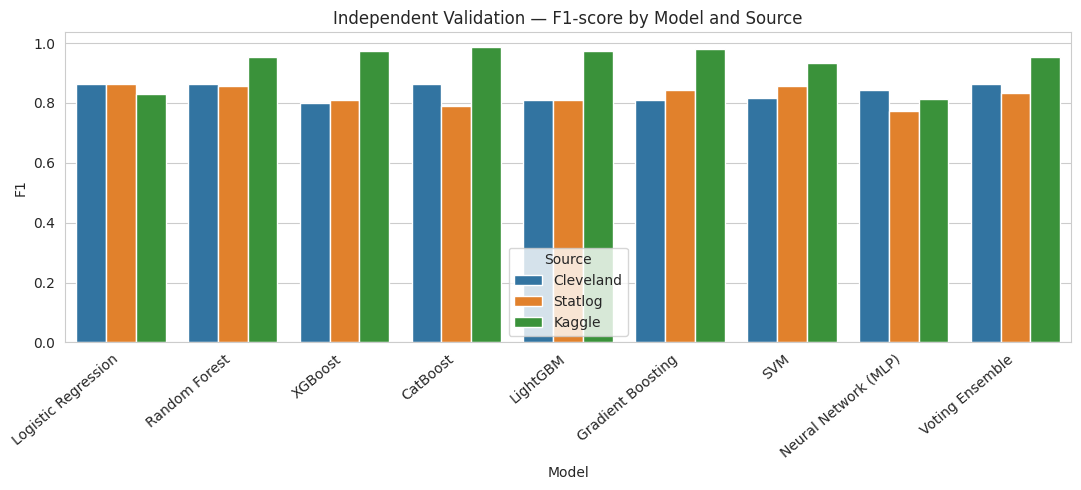

In [ ]:
plt.figure(figsize=(11, 5))
sns.barplot(data=independent_df, x="Model", y="F1", hue="Source")
plt.xticks(rotation=40, ha="right")
plt.title("Independent Validation — F1-score by Model and Source")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "independent_validation_f1.png"), dpi=200)
plt.show()

#Part 1 cell (hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# CatBoost tune korbo Kaggle-er jonno (already best model chilo)
cat_param_grid = {
    "iterations": [200, 300, 500],
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
}

grid_cat = GridSearchCV(
    CatBoostClassifier(random_state=RANDOM_STATE, verbose=False),
    cat_param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid_cat.fit(scaled["Kaggle"]["X_train"], scaled["Kaggle"]["y_train"])

best_cat = grid_cat.best_estimator_
metrics, _ = train_and_evaluate(best_cat, scaled["Kaggle"]["X_train"], scaled["Kaggle"]["y_train"],
                                  scaled["Kaggle"]["X_test"], scaled["Kaggle"]["y_test"])

print("Best params:", grid_cat.best_params_)
print(f"Tuned CatBoost — Kaggle: Accuracy={metrics['Accuracy']:.3f}  F1={metrics['F1']:.3f}  ROC-AUC={metrics['ROC-AUC']:.3f}")

Best params: {'depth': 6, 'iterations': 300, 'learning_rate': 0.03}
Tuned CatBoost — Kaggle: Accuracy=0.987  F1=0.987  ROC-AUC=0.983


In [ ]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression tune korbo Cleveland ar Statlog-er jonno (already best model chilo oikhane)
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
}

tuned_lr_results = []

for source_name in ["Cleveland", "Statlog"]:
    d = scaled[source_name]
    grid_lr = GridSearchCV(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        lr_param_grid, cv=5, scoring="f1", n_jobs=-1
    )
    grid_lr.fit(d["X_train"], d["y_train"])

    best_lr = grid_lr.best_estimator_
    metrics, _ = train_and_evaluate(best_lr, d["X_train"], d["y_train"], d["X_test"], d["y_test"])
    metrics["Source"] = source_name
    tuned_lr_results.append(metrics)

    print(f"{source_name}: best params={grid_lr.best_params_}")
    print(f"  Accuracy={metrics['Accuracy']:.3f}  F1={metrics['F1']:.3f}  ROC-AUC={metrics['ROC-AUC']:.3f}")

tuned_lr_df = pd.DataFrame(tuned_lr_results)[["Source","Accuracy","Precision","Recall","F1","ROC-AUC"]]
tuned_lr_df

Cleveland: best params={'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
  Accuracy=0.891  F1=0.884  ROC-AUC=0.954
Statlog: best params={'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Accuracy=0.902  F1=0.889  ROC-AUC=0.911


,Source,Accuracy,Precision,Recall,F1,ROC-AUC
0,Cleveland,0.891304,0.863636,0.904762,0.883721,0.954286
1,Statlog,0.902439,0.888889,0.888889,0.888889,0.910628


In [ ]:
# CatBoost metrics-ta age-i alada variable-e save kore rakhi (jate overwrite na hoy)
kaggle_tuned_metrics = metrics.copy() if "Accuracy" in metrics else None

# Actually, safest way: CatBoost cell abar run kore fresh metrics ber kori
best_cat = grid_cat.best_estimator_
kaggle_tuned_metrics, _ = train_and_evaluate(
    best_cat, scaled["Kaggle"]["X_train"], scaled["Kaggle"]["y_train"],
    scaled["Kaggle"]["X_test"], scaled["Kaggle"]["y_test"]
)
print("Kaggle tuned CatBoost:", kaggle_tuned_metrics)

# Ekhon shothik summary table
tuned_summary = pd.DataFrame([
    {"Source": "Cleveland", "Model": "Logistic Regression (tuned)",
     **tuned_lr_df[tuned_lr_df["Source"]=="Cleveland"][["Accuracy","Precision","Recall","F1","ROC-AUC"]].iloc[0].to_dict()},
    {"Source": "Statlog", "Model": "Logistic Regression (tuned)",
     **tuned_lr_df[tuned_lr_df["Source"]=="Statlog"][["Accuracy","Precision","Recall","F1","ROC-AUC"]].iloc[0].to_dict()},
    {"Source": "Kaggle", "Model": "CatBoost (tuned)", **kaggle_tuned_metrics},
])

tuned_avg = tuned_summary[["Accuracy","Precision","Recall","F1","ROC-AUC"]].mean()
print("\nTuned Independent Validation — Average across 3 sources:")
print(tuned_avg)

tuned_summary.to_csv(os.path.join(OUT_DIR, "tuned_independent_summary.csv"), index=False)
tuned_summary

Kaggle tuned CatBoost: {'Accuracy': 0.9871794871794872, 'Precision': 1.0, 'Recall': 0.9736842105263158, 'F1': 0.9866666666666667, 'ROC-AUC': np.float64(0.9832236842105263)}

Tuned Independent Validation — Average across 3 sources:
Accuracy     0.926974
Precision    0.917508
Recall       0.922445
F1           0.919759
ROC-AUC      0.949379
dtype: float64


,Source,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Cleveland,Logistic Regression (tuned),0.891304,0.863636,0.904762,0.883721,0.954286
1,Statlog,Logistic Regression (tuned),0.902439,0.888889,0.888889,0.888889,0.910628
2,Kaggle,CatBoost (tuned),0.987179,1.000000,0.973684,0.986667,0.983224


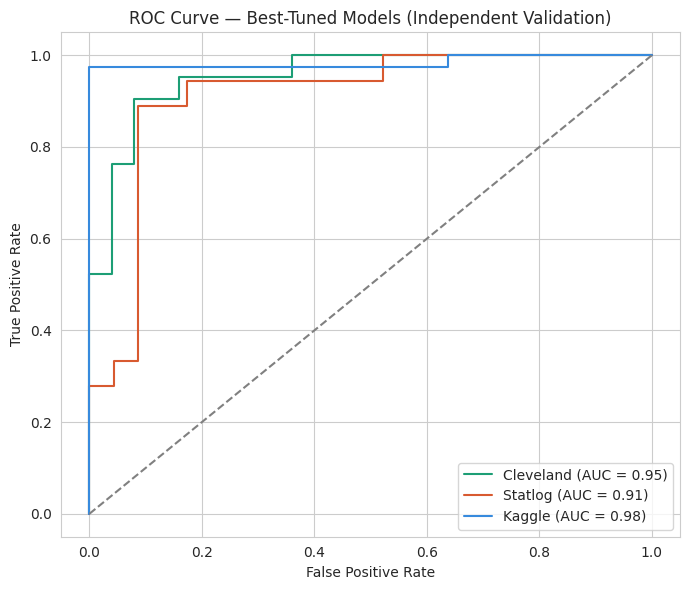

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,6))
colors = {"Cleveland": "#1D9E75", "Statlog": "#D85A30", "Kaggle": "#378ADD"}

# Cleveland & Statlog: tuned Logistic Regression
for source_name in ["Cleveland", "Statlog"]:
    d = scaled[source_name]
    best_params = grid_lr.best_params_ if source_name=="Statlog" else {"C":0.01,"penalty":"l2","solver":"lbfgs"}
    model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **best_params)
    model.fit(d["X_train"], d["y_train"])
    y_proba = model.predict_proba(d["X_test"])[:,1]
    fpr, tpr, _ = roc_curve(d["y_test"], y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{source_name} (AUC = {roc_auc:.2f})", color=colors[source_name])

# Kaggle: tuned CatBoost
d = scaled["Kaggle"]
model = grid_cat.best_estimator_
y_proba = model.predict_proba(d["X_test"])[:,1]
fpr, tpr, _ = roc_curve(d["y_test"], y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"Kaggle (AUC = {roc_auc:.2f})", color=colors["Kaggle"])

plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Best-Tuned Models (Independent Validation)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve_independent.png"), dpi=200)
plt.show()

In [ ]:
import time

cost_rows = []
best_models_by_source = {
    "Cleveland": lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, C=0.01, penalty="l2", solver="lbfgs"),
    "Statlog": lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, C=grid_lr.best_params_["C"], penalty=grid_lr.best_params_["penalty"], solver=grid_lr.best_params_["solver"]),
    "Kaggle": lambda: CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, **grid_cat.best_params_),
}

for source_name, fn in best_models_by_source.items():
    d = scaled[source_name]
    model = fn()

    t0 = time.time()
    model.fit(d["X_train"], d["y_train"])
    train_time = time.time() - t0

    t0 = time.time()
    _ = model.predict(d["X_test"])
    infer_time = (time.time() - t0) / len(d["X_test"]) * 1000  # ms per sample

    cost_rows.append({
        "Source": source_name,
        "Model": type(model).__name__,
        "Train Time (s)": round(train_time, 3),
        "Inference Time (ms/sample)": round(infer_time, 4),
    })

cost_df = pd.DataFrame(cost_rows)
cost_df.to_csv(os.path.join(OUT_DIR, "table_computational_cost.csv"), index=False)
cost_df

,Source,Model,Train Time (s),Inference Time (ms/sample)
0,Cleveland,LogisticRegression,0.032,0.1138
1,Statlog,LogisticRegression,0.011,0.0689
2,Kaggle,CatBoostClassifier,0.760,0.0101


#Section 13-er tuning cell-gulor por, notun cell:

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def repeated_cv_eval(model_fn, X, y, n_splits=5, n_repeats=10, seed=RANDOM_STATE):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    fold_metrics = []
    for train_idx, test_idx in rskf.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler().fit(X_tr)
        X_tr_s = pd.DataFrame(scaler.transform(X_tr), columns=X.columns)
        X_te_s = pd.DataFrame(scaler.transform(X_te), columns=X.columns)

        model = model_fn()
        model.fit(X_tr_s, y_tr)
        y_pred = model.predict(X_te_s)
        y_proba = model.predict_proba(X_te_s)[:,1]

        fold_metrics.append({
            "Accuracy": accuracy_score(y_te, y_pred),
            "Precision": precision_score(y_te, y_pred, zero_division=0),
            "Recall": recall_score(y_te, y_pred, zero_division=0),
            "F1": f1_score(y_te, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_te, y_proba),
        })
    return pd.DataFrame(fold_metrics)

# Best-tuned model per source (matching Table IV selections)
model_fns = {
    "Cleveland": lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, C=0.01, penalty="l2", solver="lbfgs"),
    "Statlog":   lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **grid_lr.best_params_) if False else lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, C=grid_lr.best_params_["C"], penalty=grid_lr.best_params_["penalty"], solver=grid_lr.best_params_["solver"]),
    "Kaggle":    lambda: CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, **grid_cat.best_params_),
}

repeated_cv_results = []
for source_name in ["Cleveland", "Statlog", "Kaggle"]:
    X = data_final[source_name][UNIFIED_COLUMNS[:-1]]
    y = data_final[source_name]["target"]
    if source_name == "Cleveland":
        fn = lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, C=0.01, penalty="l2", solver="lbfgs")
    elif source_name == "Statlog":
        fn = lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                         C=grid_lr.best_params_["C"],
                                         penalty=grid_lr.best_params_["penalty"],
                                         solver=grid_lr.best_params_["solver"])
    else:
        fn = lambda: CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, **grid_cat.best_params_)

    df_fold = repeated_cv_eval(fn, X, y, n_splits=5, n_repeats=10)
    summary_mean = df_fold.mean().to_dict()
    summary_std = df_fold.std().to_dict()
    row = {"Source": source_name}
    for k in ["Accuracy","Precision","Recall","F1","ROC-AUC"]:
        row[f"{k}_mean"] = summary_mean[k]
        row[f"{k}_std"] = summary_std[k]
    repeated_cv_results.append(row)

repeated_cv_df = pd.DataFrame(repeated_cv_results)
repeated_cv_df.to_csv(os.path.join(OUT_DIR, "table_IV_repeated_kfold.csv"), index=False)
repeated_cv_df

,Source,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,ROC-AUC_mean,ROC-AUC_std
0,Cleveland,0.839967,0.043437,0.878889,0.058388,0.758360,0.069880,0.812140,0.051846,0.906359,0.033967
1,Statlog,0.844444,0.043470,0.849716,0.060462,0.794167,0.077340,0.818448,0.053627,0.909250,0.033011
2,Kaggle,0.991304,0.007497,0.989654,0.011746,0.992650,0.010787,0.991081,0.007704,0.998866,0.001685


#14. Cross-Dataset Validation — 6 Experiments
Each model trains on the full data of one source and is tested on the full data of a different source (true external validation — the test source is never seen during training or scaling).

Exp	Train → Test

1	Cleveland → Statlog

2	Statlog → Cleveland

3	Cleveland → Kaggle

4	Kaggle → Cleveland

5	Statlog → Kaggle

6	Kaggle → Statlog


In [ ]:
EXPERIMENTS = [
    ("Cleveland", "Statlog"),
    ("Statlog", "Cleveland"),
    ("Cleveland", "Kaggle"),
    ("Kaggle", "Cleveland"),
    ("Statlog", "Kaggle"),
    ("Kaggle", "Statlog"),
]

cross_results = []
fitted_cross_models = {}     # {(train_src, test_src, model_name): fitted model}
cross_scalers = {}           # {(train_src, test_src): scaler fit on train_src}
cross_test_data = {}         # {(train_src, test_src): (X_test_scaled, y_test)} for SHAP/LIME later

for exp_num, (train_src, test_src) in enumerate(EXPERIMENTS, start=1):
    X_train_raw = data_final[train_src][UNIFIED_COLUMNS[:-1]]
    y_train     = data_final[train_src]["target"]
    X_test_raw  = data_final[test_src][UNIFIED_COLUMNS[:-1]]
    y_test      = data_final[test_src]["target"]

    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=UNIFIED_COLUMNS[:-1])
    X_test  = pd.DataFrame(scaler.transform(X_test_raw), columns=UNIFIED_COLUMNS[:-1])
    cross_scalers[(train_src, test_src)] = scaler
    cross_test_data[(train_src, test_src)] = (X_test, y_test.reset_index(drop=True))

    models = get_models()
    for model_name, model in models.items():
        metrics, fitted = train_and_evaluate(model, X_train, y_train, X_test, y_test)
        metrics.update({"Experiment": f"Exp{exp_num}", "Train": train_src,
                         "Test": test_src, "Model": model_name})
        cross_results.append(metrics)
        fitted_cross_models[(train_src, test_src, model_name)] = fitted
        print(f"[{metrics['Experiment']}] {train_src}->{test_src:<10s} | {model_name:<22s} "
              f"Acc={metrics['Accuracy']:.3f}  F1={metrics['F1']:.3f}  AUC={metrics['ROC-AUC']:.3f}")

cross_df = pd.DataFrame(cross_results)[
    ["Experiment", "Train", "Test", "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
cross_df.to_csv(os.path.join(OUT_DIR, "cross_dataset_validation_results.csv"), index=False)
cross_df


[Exp1] Cleveland->Statlog    | Logistic Regression    Acc=0.848  F1=0.827  AUC=0.928
[Exp1] Cleveland->Statlog    | Random Forest          Acc=0.959  F1=0.953  AUC=0.996
[Exp1] Cleveland->Statlog    | XGBoost                Acc=1.000  F1=1.000  AUC=1.000
[Exp1] Cleveland->Statlog    | CatBoost               Acc=1.000  F1=1.000  AUC=1.000
[Exp1] Cleveland->Statlog    | LightGBM               Acc=1.000  F1=1.000  AUC=1.000
[Exp1] Cleveland->Statlog    | Gradient Boosting      Acc=0.996  F1=0.996  AUC=1.000
[Exp1] Cleveland->Statlog    | SVM                    Acc=0.915  F1=0.902  AUC=0.961
[Exp1] Cleveland->Statlog    | Neural Network (MLP)   Acc=0.819  F1=0.795  AUC=0.894
[Exp1] Cleveland->Statlog    | Voting Ensemble        Acc=0.963  F1=0.958  AUC=0.997
[Exp2] Statlog->Cleveland  | Logistic Regression    Acc=0.848  F1=0.827  AUC=0.923
[Exp2] Statlog->Cleveland  | Random Forest          Acc=0.954  F1=0.948  AUC=0.991
[Exp2] Statlog->Cleveland  | XGBoost                Acc=0.974  F1=0.9

,Experiment,Train,Test,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Exp1,Cleveland,Statlog,Logistic Regression,0.848148,0.837607,0.816667,0.827004,0.928500
1,Exp1,Cleveland,Statlog,Random Forest,0.959259,0.973913,0.933333,0.953191,0.996111
2,Exp1,Cleveland,Statlog,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
3,Exp1,Cleveland,Statlog,CatBoost,1.000000,1.000000,1.000000,1.000000,1.000000
4,Exp1,Cleveland,Statlog,LightGBM,1.000000,1.000000,1.000000,1.000000,1.000000
5,Exp1,Cleveland,Statlog,Gradient Boosting,0.996296,1.000000,0.991667,0.995816,1.000000
6,Exp1,Cleveland,Statlog,SVM,0.914815,0.921739,0.883333,0.902128,0.961222
7,Exp1,Cleveland,Statlog,Neural Network (MLP),0.818519,0.798319,0.791667,0.794979,0.893778
8,Exp1,Cleveland,Statlog,Voting Ensemble,0.962963,0.974138,0.941667,0.957627,0.996556
9,Exp2,Statlog,Cleveland,Logistic Regression,0.848185,0.866142,0.791367,0.827068,0.923144


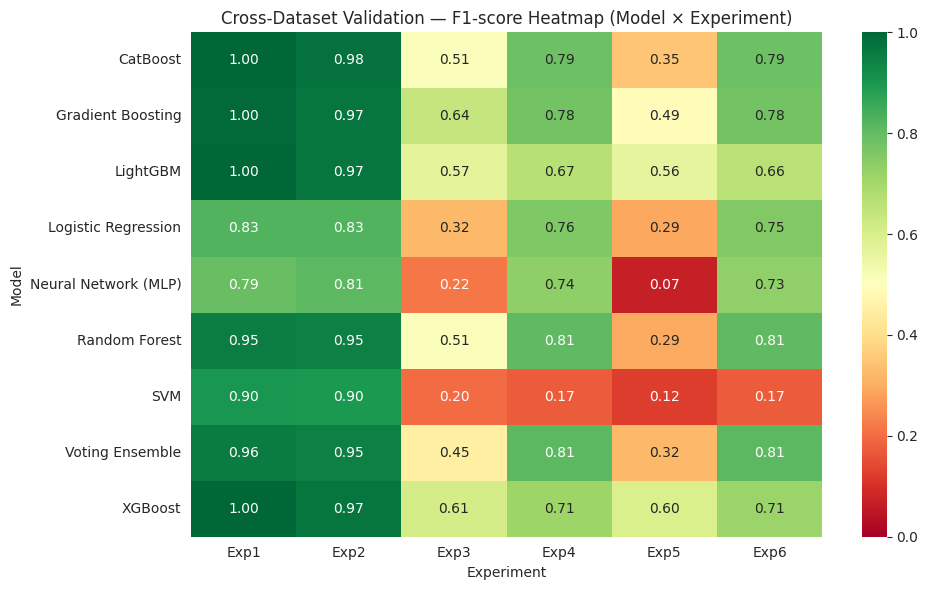

In [ ]:
pivot = cross_df.pivot_table(index="Model", columns="Experiment", values="F1")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1)
plt.title("Cross-Dataset Validation — F1-score Heatmap (Model × Experiment)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cross_dataset_f1_heatmap.png"), dpi=200)
plt.show()

In [ ]:
# Independent vs. cross-dataset performance gap (generalization drop), per model
indep_avg = independent_df.groupby("Model")["F1"].mean().rename("Independent_F1_avg")
cross_avg = cross_df.groupby("Model")["F1"].mean().rename("Cross_F1_avg")
gap = pd.concat([indep_avg, cross_avg], axis=1)
gap["Generalization_Gap"] = gap["Independent_F1_avg"] - gap["Cross_F1_avg"]
gap.sort_values("Generalization_Gap")

,Independent_F1_avg,Cross_F1_avg,Generalization_Gap
Model,,,
XGBoost,0.861498,0.766807,0.094691
Gradient Boosting,0.877254,0.774838,0.102416
LightGBM,0.864673,0.738205,0.126468
CatBoost,0.879926,0.734485,0.145441
Voting Ensemble,0.883537,0.716195,0.167343
Random Forest,0.891053,0.719317,0.171737
Logistic Regression,0.852358,0.630282,0.222075
Neural Network (MLP),0.810322,0.559403,0.250918
SVM,0.869845,0.411005,0.458840


In [ ]:
# Part 2: Cross-dataset validation using only the most XAI-stable features
# (cp, ca, thal, sex, age were the top-5 most consistently important features
# from the Cross-Dataset XAI Stability analysis)

STABLE_FEATURES = ["cp", "ca", "thal", "sex", "age", "thalach", "oldpeak", "exang"]

stable_cross_results = []

for exp_num, (train_src, test_src) in enumerate(EXPERIMENTS, start=1):
    X_train_raw = data_final[train_src][STABLE_FEATURES]
    y_train     = data_final[train_src]["target"]
    X_test_raw  = data_final[test_src][STABLE_FEATURES]
    y_test      = data_final[test_src]["target"]

    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=STABLE_FEATURES)
    X_test  = pd.DataFrame(scaler.transform(X_test_raw), columns=STABLE_FEATURES)

    models = get_models()
    for model_name, model in models.items():
        metrics, fitted = train_and_evaluate(model, X_train, y_train, X_test, y_test)
        metrics.update({"Experiment": f"Exp{exp_num}", "Train": train_src,
                         "Test": test_src, "Model": model_name})
        stable_cross_results.append(metrics)

stable_cross_df = pd.DataFrame(stable_cross_results)[
    ["Experiment","Train","Test","Model","Accuracy","Precision","Recall","F1","ROC-AUC"]]
stable_cross_df.to_csv(os.path.join(OUT_DIR, "stable_feature_cross_dataset.csv"), index=False)

# Compare original (13-feature) vs stable-feature-only average F1
print("Original (13 features) avg F1:", cross_df["F1"].mean())
print("Stable-feature-only (8 features) avg F1:", stable_cross_df["F1"].mean())

stable_cross_df.sort_values(["Experiment","F1"], ascending=[True, False])

Original (13 features) avg F1: 0.6722817814146199
Stable-feature-only (8 features) avg F1: 0.7512916663631273


,Experiment,Train,Test,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,Exp1,Cleveland,Statlog,CatBoost,1.000000,1.000000,1.000000,1.000000,1.000000
4,Exp1,Cleveland,Statlog,LightGBM,1.000000,1.000000,1.000000,1.000000,1.000000
2,Exp1,Cleveland,Statlog,XGBoost,0.996296,1.000000,0.991667,0.995816,0.999944
5,Exp1,Cleveland,Statlog,Gradient Boosting,0.992593,0.991667,0.991667,0.991667,0.999389
1,Exp1,Cleveland,Statlog,Random Forest,0.948148,0.964912,0.916667,0.940171,0.989556
8,Exp1,Cleveland,Statlog,Voting Ensemble,0.933333,0.939655,0.908333,0.923729,0.991333
6,Exp1,Cleveland,Statlog,SVM,0.888889,0.887931,0.858333,0.872881,0.946278
0,Exp1,Cleveland,Statlog,Logistic Regression,0.855556,0.852174,0.816667,0.834043,0.914944
7,Exp1,Cleveland,Statlog,Neural Network (MLP),0.848148,0.831933,0.825000,0.828452,0.906556
13,Exp2,Statlog,Cleveland,LightGBM,0.976898,1.000000,0.949640,0.974170,0.992016


In [ ]:
best_per_experiment = stable_cross_df.loc[stable_cross_df.groupby("Experiment")["F1"].idxmax()][
    ["Experiment","Train","Test","Model","Accuracy","Precision","Recall","F1","ROC-AUC"]]

best_per_experiment.to_csv(os.path.join(OUT_DIR, "table_IV_best_per_experiment.csv"), index=False)
best_per_experiment

,Experiment,Train,Test,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,Exp1,Cleveland,Statlog,CatBoost,1.000000,1.000000,1.000000,1.000000,1.000000
13,Exp2,Statlog,Cleveland,LightGBM,0.976898,1.000000,0.949640,0.974170,0.992016
20,Exp3,Cleveland,Kaggle,XGBoost,0.800966,0.971519,0.609127,0.748780,0.904837
35,Exp4,Kaggle,Cleveland,Voting Ensemble,0.821782,0.814815,0.791367,0.802920,0.911827
38,Exp5,Statlog,Kaggle,XGBoost,0.793237,0.961783,0.599206,0.738386,0.906772
53,Exp6,Kaggle,Statlog,Voting Ensemble,0.818519,0.793388,0.800000,0.796680,0.909056


In [ ]:
xgb_stable_avg = stable_cross_df[stable_cross_df["Model"]=="XGBoost"][
    ["Accuracy","Precision","Recall","F1","ROC-AUC"]].mean()
print("XGBoost (stable features) — avg across 6 experiments:")
print(xgb_stable_avg)

XGBoost (stable features) — avg across 6 experiments:
Accuracy     0.854009
Precision    0.914760
Recall       0.763090
F1           0.824435
ROC-AUC      0.930648
dtype: float64


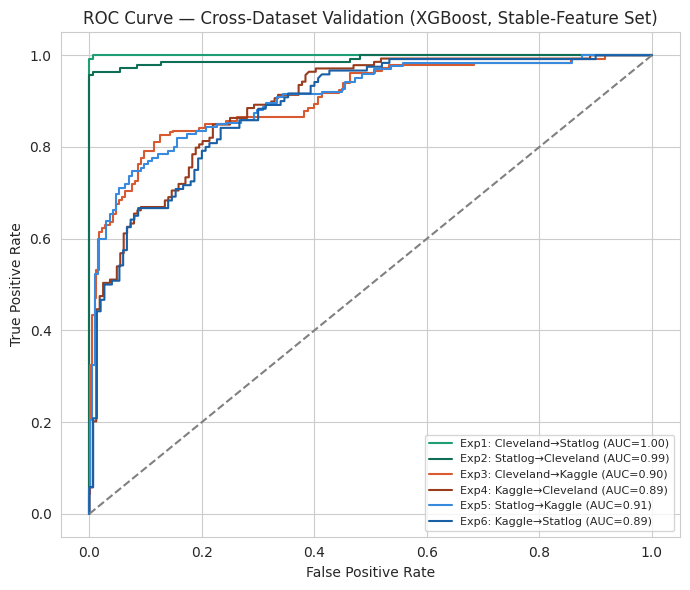

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,6))
colors_exp = {
    "Exp1": "#1D9E75", "Exp2": "#0F6E56", "Exp3": "#D85A30",
    "Exp4": "#993C1D", "Exp5": "#378ADD", "Exp6": "#185FA5"
}

for exp_num, (train_src, test_src) in enumerate(EXPERIMENTS, start=1):
    exp_label = f"Exp{exp_num}"
    X_train_raw = data_final[train_src][STABLE_FEATURES]
    y_train     = data_final[train_src]["target"]
    X_test_raw  = data_final[test_src][STABLE_FEATURES]
    y_test      = data_final[test_src]["target"]

    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=STABLE_FEATURES)
    X_test  = pd.DataFrame(scaler.transform(X_test_raw), columns=STABLE_FEATURES)

    model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{exp_label}: {train_src}→{test_src} (AUC={roc_auc:.2f})",
             color=colors_exp[exp_label])

plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Cross-Dataset Validation (XGBoost, Stable-Feature Set)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve_cross_dataset.png"), dpi=200)
plt.show()

#2️⃣ Bootstrap Confidence Intervals — Cross-Dataset Validation

In [ ]:
from sklearn.utils import resample

def bootstrap_ci(y_true, y_pred, y_proba, n_boot=1000, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    f1_scores, auc_scores = [], []
    n = len(y_true)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_proba[idx]
        if len(np.unique(yt)) < 2:
            continue  # skip degenerate resamples with only one class
        f1_scores.append(f1_score(yt, yp, zero_division=0))
        auc_scores.append(roc_auc_score(yt, ypr))

    f1_scores = np.array(f1_scores)
    auc_scores = np.array(auc_scores)
    return {
        "F1_mean": f1_scores.mean(), "F1_CI_low": np.percentile(f1_scores, 2.5), "F1_CI_high": np.percentile(f1_scores, 97.5),
        "AUC_mean": auc_scores.mean(), "AUC_CI_low": np.percentile(auc_scores, 2.5), "AUC_CI_high": np.percentile(auc_scores, 97.5),
    }

bootstrap_results = []
for exp_num, (train_src, test_src) in enumerate(EXPERIMENTS, start=1):
    X_train_raw = data_final[train_src][STABLE_FEATURES]
    y_train     = data_final[train_src]["target"]
    X_test_raw  = data_final[test_src][STABLE_FEATURES]
    y_test      = data_final[test_src]["target"]

    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=STABLE_FEATURES)
    X_test  = pd.DataFrame(scaler.transform(X_test_raw), columns=STABLE_FEATURES)

    model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    ci = bootstrap_ci(y_test.values, y_pred, y_proba, n_boot=1000)
    ci.update({"Experiment": f"Exp{exp_num}", "Train": train_src, "Test": test_src})
    bootstrap_results.append(ci)
    print(f"Exp{exp_num} {train_src}->{test_src}: "
          f"F1={ci['F1_mean']:.3f} [{ci['F1_CI_low']:.3f}, {ci['F1_CI_high']:.3f}]  "
          f"AUC={ci['AUC_mean']:.3f} [{ci['AUC_CI_low']:.3f}, {ci['AUC_CI_high']:.3f}]")

bootstrap_df = pd.DataFrame(bootstrap_results)[
    ["Experiment","Train","Test","F1_mean","F1_CI_low","F1_CI_high","AUC_mean","AUC_CI_low","AUC_CI_high"]]
bootstrap_df.to_csv(os.path.join(OUT_DIR, "table_bootstrap_ci_cross_dataset.csv"), index=False)
bootstrap_df

Exp1 Cleveland->Statlog: F1=0.996 [0.987, 1.000]  AUC=1.000 [1.000, 1.000]
Exp2 Statlog->Cleveland: F1=0.971 [0.948, 0.990]  AUC=0.991 [0.980, 0.999]
Exp3 Cleveland->Kaggle: F1=0.749 [0.715, 0.782]  AUC=0.905 [0.886, 0.922]
Exp4 Kaggle->Cleveland: F1=0.751 [0.693, 0.803]  AUC=0.894 [0.856, 0.926]
Exp5 Statlog->Kaggle: F1=0.739 [0.704, 0.772]  AUC=0.907 [0.888, 0.924]
Exp6 Kaggle->Statlog: F1=0.742 [0.673, 0.802]  AUC=0.888 [0.843, 0.922]


,Experiment,Train,Test,F1_mean,F1_CI_low,F1_CI_high,AUC_mean,AUC_CI_low,AUC_CI_high
0,Exp1,Cleveland,Statlog,0.995860,0.986658,1.000000,0.999948,0.999670,1.000000
1,Exp2,Statlog,Cleveland,0.970576,0.947761,0.989549,0.991130,0.979952,0.999111
2,Exp3,Cleveland,Kaggle,0.749432,0.715025,0.782099,0.905050,0.885836,0.922363
3,Exp4,Kaggle,Cleveland,0.750687,0.692632,0.802921,0.894105,0.856389,0.926099
4,Exp5,Statlog,Kaggle,0.738585,0.704188,0.772326,0.906920,0.888034,0.923520
5,Exp6,Kaggle,Statlog,0.741569,0.672575,0.801653,0.887561,0.842747,0.922242


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar(y_true, y_pred_1, y_pred_2):
    y_true = np.array(y_true)
    correct_1 = (y_pred_1 == y_true)
    correct_2 = (y_pred_2 == y_true)

    n01 = np.sum(correct_1 & ~correct_2)  # model 1 right, model 2 wrong
    n10 = np.sum(~correct_1 & correct_2)  # model 1 wrong, model 2 right
    table = [[0, n01], [n10, 0]]
    result = mcnemar(table, exact=(n01 + n10 < 25))
    return result.pvalue, n01, n10

# Compare XGBoost (smallest generalization gap) vs SVM (largest gap) across all 6 cross-dataset experiments
mcnemar_results = []
for exp_num, (train_src, test_src) in enumerate(EXPERIMENTS, start=1):
    X_train_raw = data_final[train_src][UNIFIED_COLUMNS[:-1]]
    y_train     = data_final[train_src]["target"]
    X_test_raw  = data_final[test_src][UNIFIED_COLUMNS[:-1]]
    y_test      = data_final[test_src]["target"]

    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=UNIFIED_COLUMNS[:-1])
    X_test  = pd.DataFrame(scaler.transform(X_test_raw), columns=UNIFIED_COLUMNS[:-1])

    xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                         eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)
    svm = SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE)

    xgb.fit(X_train, y_train)
    svm.fit(X_train, y_train)

    pred_xgb = xgb.predict(X_test)
    pred_svm = svm.predict(X_test)

    pval, n01, n10 = run_mcnemar(y_test.values, pred_xgb, pred_svm)
    mcnemar_results.append({
        "Experiment": f"Exp{exp_num}", "Train": train_src, "Test": test_src,
        "XGB_only_correct": n01, "SVM_only_correct": n10, "p_value": pval,
        "Significant (p<0.05)": "Yes" if pval < 0.05 else "No"
    })
    print(f"Exp{exp_num} {train_src}->{test_src}: p={pval:.4f}  "
          f"({'significant' if pval < 0.05 else 'not significant'})")

mcnemar_df = pd.DataFrame(mcnemar_results)
mcnemar_df.to_csv(os.path.join(OUT_DIR, "table_mcnemar_xgb_vs_svm.csv"), index=False)
mcnemar_df

Exp1 Cleveland->Statlog: p=0.0000  (significant)
Exp2 Statlog->Cleveland: p=0.0001  (significant)
Exp3 Cleveland->Kaggle: p=0.0000  (significant)
Exp4 Kaggle->Cleveland: p=0.0000  (significant)
Exp5 Statlog->Kaggle: p=0.0000  (significant)
Exp6 Kaggle->Statlog: p=0.0000  (significant)


,Experiment,Train,Test,XGB_only_correct,SVM_only_correct,p_value,Significant (p<0.05)
0,Exp1,Cleveland,Statlog,23,0,2.384186e-07,Yes
1,Exp2,Statlog,Cleveland,21,2,6.604195e-05,Yes
2,Exp3,Cleveland,Kaggle,202,29,1.083934e-29,Yes
3,Exp4,Kaggle,Cleveland,83,8,8.675121e-15,Yes
4,Exp5,Statlog,Kaggle,200,16,1.371161e-35,Yes
5,Exp6,Kaggle,Statlog,74,8,7.071312e-13,Yes


#Code 2 — Confusion matrix breakdown table (notun cell, Section 14-er por):

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_rows = []

# Independent validation — best-tuned model per source
indep_models = {"Cleveland": ("Logistic Regression (tuned)", grid_lr.best_estimator_ if False else None)}
for source_name in ["Cleveland","Statlog","Kaggle"]:
    d = scaled[source_name]
    if source_name == "Kaggle":
        model = grid_cat.best_estimator_
    else:
        best_params = grid_lr.best_params_ if source_name=="Statlog" else {"C":0.01,"penalty":"l2","solver":"lbfgs"}
        model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **best_params)
        model.fit(d["X_train"], d["y_train"])
    y_pred = model.predict(d["X_test"])
    tn, fp, fn, tp = confusion_matrix(d["y_test"], y_pred).ravel()
    confusion_rows.append({"Setting":"Independent Validation","Source/Experiment":source_name,
                            "TP":tp,"TN":tn,"FP":fp,"FN":fn})

# Cross-dataset validation — XGBoost, stable-feature set, all 6 experiments
for exp_num, (train_src, test_src) in enumerate(EXPERIMENTS, start=1):
    X_train_raw = data_final[train_src][STABLE_FEATURES]
    y_train = data_final[train_src]["target"]
    X_test_raw = data_final[test_src][STABLE_FEATURES]
    y_test = data_final[test_src]["target"]
    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=STABLE_FEATURES)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=STABLE_FEATURES)
    model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    confusion_rows.append({"Setting":"Cross-Dataset Validation","Source/Experiment":f"Exp{exp_num}: {train_src}→{test_src}",
                            "TP":tp,"TN":tn,"FP":fp,"FN":fn})

confusion_df = pd.DataFrame(confusion_rows)
confusion_df.to_csv(os.path.join(OUT_DIR, "confusion_matrix_breakdown.csv"), index=False)
confusion_df

,Setting,Source/Experiment,TP,TN,FP,FN
0,Independent Validation,Cleveland,19,22,3,2
1,Independent Validation,Statlog,16,21,2,2
2,Independent Validation,Kaggle,74,80,0,2
3,Cross-Dataset Validation,Exp1: Cleveland→Statlog,119,150,0,1
4,Cross-Dataset Validation,Exp2: Statlog→Cleveland,131,164,0,8
5,Cross-Dataset Validation,Exp3: Cleveland→Kaggle,307,522,9,197
6,Cross-Dataset Validation,Exp4: Kaggle→Cleveland,100,137,27,39
7,Cross-Dataset Validation,Exp5: Statlog→Kaggle,302,519,12,202
8,Cross-Dataset Validation,Exp6: Kaggle→Statlog,86,124,26,34


#15. SHAP + LIME Explainability — Core Contribution
Applied to XGBoost (fast, robust TreeExplainer support) trained in each of the 6 cross-dataset experiments. SHAP gives a global view (which features matter overall); LIME gives a local view (why one specific patient was classified the way they were). Swap XAI_MODEL_NAME to explain a different model.


=== SHAP global summary: Cleveland -> Statlog (XGBoost) ===


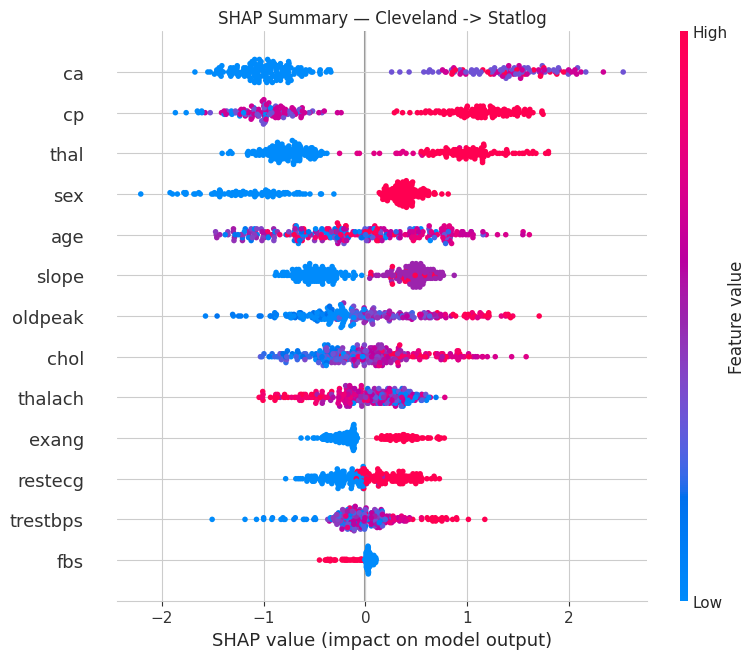


=== SHAP global summary: Statlog -> Cleveland (XGBoost) ===


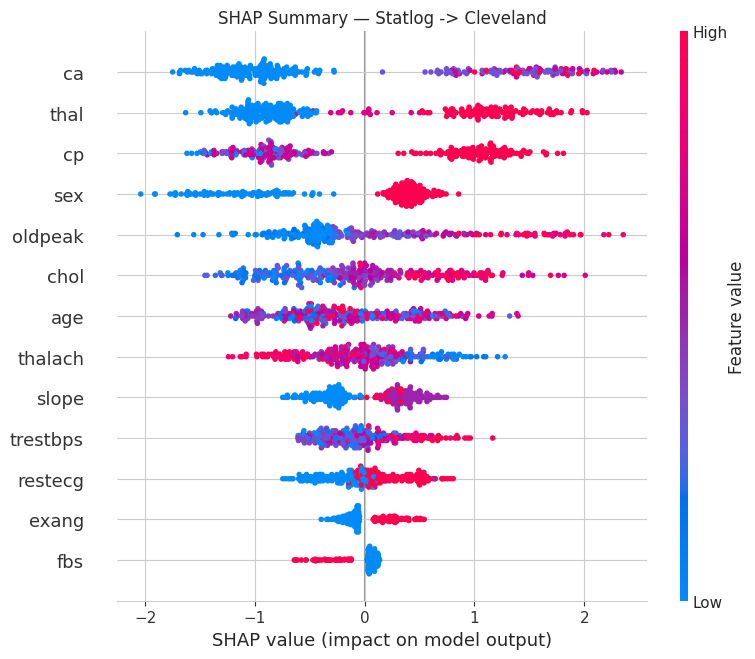


=== SHAP global summary: Cleveland -> Kaggle (XGBoost) ===


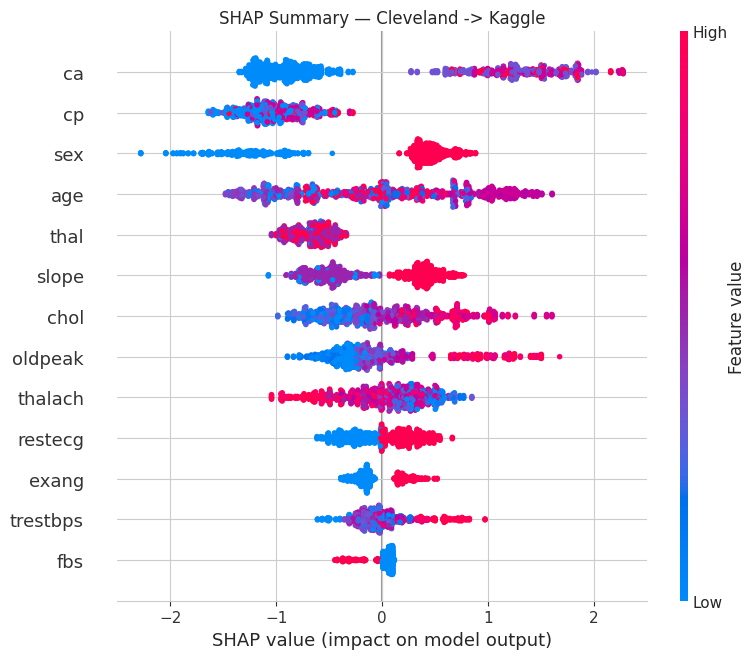


=== SHAP global summary: Kaggle -> Cleveland (XGBoost) ===


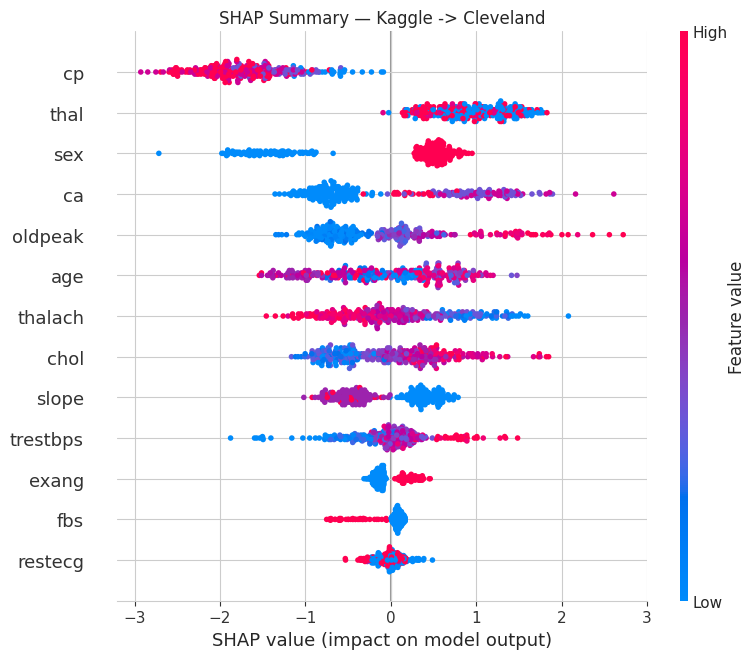


=== SHAP global summary: Statlog -> Kaggle (XGBoost) ===


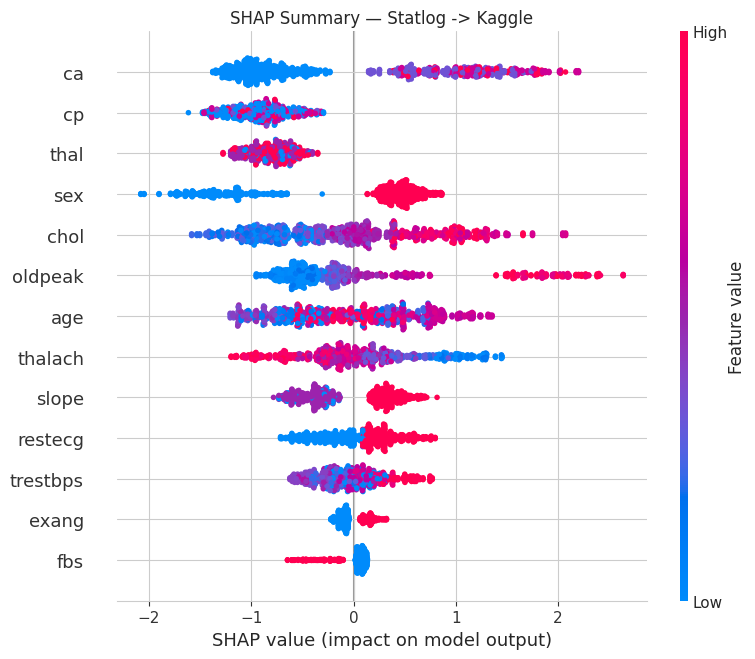


=== SHAP global summary: Kaggle -> Statlog (XGBoost) ===


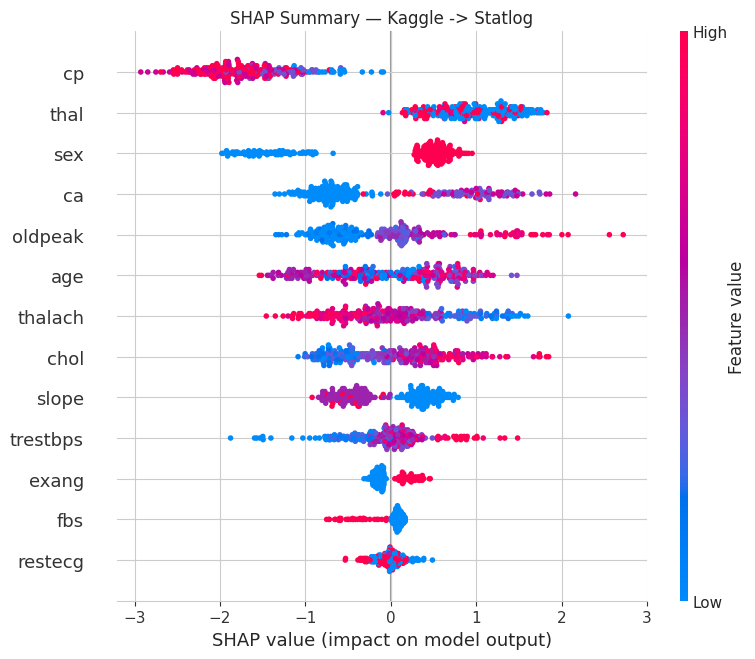

In [ ]:
XAI_MODEL_NAME = "XGBoost"   # must be a tree model for fast TreeExplainer support
FEATURE_NAMES = UNIFIED_COLUMNS[:-1]

shap_importances = {}  # {(train_src, test_src): pd.Series of mean |SHAP value| per feature}

for (train_src, test_src) in EXPERIMENTS:
    model = fitted_cross_models[(train_src, test_src, XAI_MODEL_NAME)]
    X_test, y_test = cross_test_data[(train_src, test_src)]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    # XGBClassifier binary output: shap_values is a single array (n_samples, n_features)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_NAMES)
    shap_importances[(train_src, test_src)] = mean_abs_shap

    print(f"\n=== SHAP global summary: {train_src} -> {test_src} ({XAI_MODEL_NAME}) ===")
    shap.summary_plot(shap_values, X_test, feature_names=FEATURE_NAMES, show=False)
    plt.title(f"SHAP Summary — {train_src} -> {test_src}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"shap_summary_{train_src}_to_{test_src}.png"), dpi=200, bbox_inches="tight")
    plt.show()

In [ ]:
# LIME local explanation — one example patient per experiment
lime_explanations = {}
_
for (train_src, test_src) in EXPERIMENTS:
    model = fitted_cross_models[(train_src, test_src, XAI_MODEL_NAME)]
    X_train_raw = data_final[train_src][FEATURE_NAMES]
    scaler = cross_scalers[(train_src, test_src)]
    X_train_scaled = scaler.transform(X_train_raw)
    X_test, y_test = cross_test_data[(train_src, test_src)]

    explainer = LimeTabularExplainer(
        training_data=X_train_scaled,
        feature_names=FEATURE_NAMES,
        class_names=["No Disease", "Disease"],
        mode="classification",
        random_state=RANDOM_STATE)

    sample_idx = 0  # change to inspect a different patient
    exp = explainer.explain_instance(
        X_test.iloc[sample_idx].values, model.predict_proba, num_features=8)
    lime_explanations[(train_src, test_src)] = exp

    print(f"\n=== LIME local explanation: {train_src} -> {test_src}, "
          f"patient #{sample_idx} (true label={y_test.iloc[sample_idx]}) ===")
    for feature, weight in exp.as_list():
        print(f"  {feature:<30s} {weight:+.4f}")



=== LIME local explanation: Cleveland -> Statlog, patient #0 (true label=1) ===
  ca > 0.36                      +0.3406
  -0.17 < cp <= 0.88             +0.2178
  -1.46 < sex <= 0.69            +0.1720
  thal <= -0.89                  -0.1207
  -0.98 < slope <= 0.65          +0.1196
  oldpeak > 0.48                 +0.1157
  exang <= -0.70                 -0.0975
  thalach <= -0.71               +0.0947

=== LIME local explanation: Statlog -> Cleveland, patient #0 (true label=0) ===
  ca <= -0.71                    -0.4834
  -1.45 < sex <= 0.69            +0.1851
  oldpeak > 0.48                 +0.1697
  cp <= -0.18                    -0.1641
  -0.88 < thal <= 1.19           +0.1063
  -0.71 < chol <= -0.09          -0.0747
  trestbps > 0.49                +0.0620
  exang <= -0.70                 -0.0517

=== LIME local explanation: Cleveland -> Kaggle, patient #0 (true label=1) ===
  -0.71 < ca <= 0.36             +0.3239
  cp <= -0.17                    -0.2121
  -1.46 < sex <= 0.6

#Code 1 — LIME plot (Section 15-er por, notun cell):

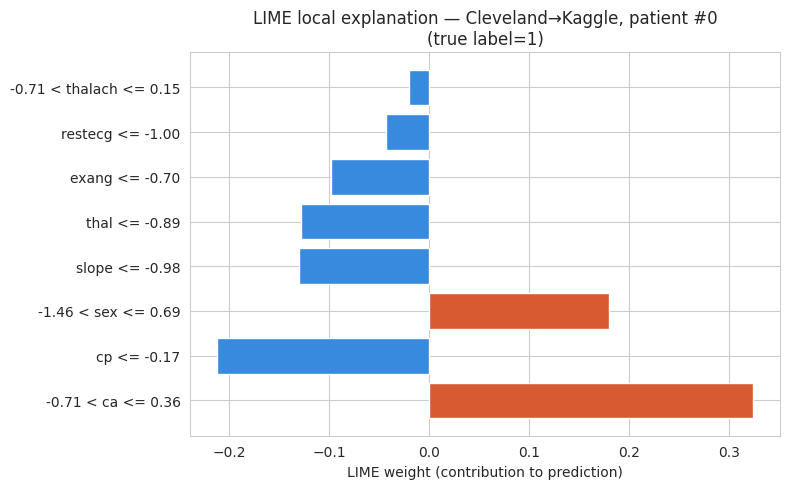

In [ ]:
import matplotlib.pyplot as plt

# LIME explanation as a bar chart for one representative cross-dataset experiment
exp_choice = ("Cleveland", "Kaggle")
model = fitted_cross_models[(exp_choice[0], exp_choice[1], "XGBoost")]
X_test, y_test = cross_test_data[exp_choice]
scaler = cross_scalers[exp_choice]
X_train_raw = data_final[exp_choice[0]][FEATURE_NAMES]
X_train_scaled = scaler.transform(X_train_raw)

explainer = LimeTabularExplainer(X_train_scaled, feature_names=FEATURE_NAMES,
                                  class_names=["No Disease","Disease"], mode="classification",
                                  random_state=RANDOM_STATE)
sample_idx = 0
exp = explainer.explain_instance(X_test.iloc[sample_idx].values, model.predict_proba, num_features=8)

features, weights = zip(*exp.as_list())
colors = ["#D85A30" if w>0 else "#378ADD" for w in weights]

plt.figure(figsize=(8,5))
plt.barh(features, weights, color=colors)
plt.xlabel("LIME weight (contribution to prediction)")
plt.title(f"LIME local explanation — {exp_choice[0]}→{exp_choice[1]}, patient #{sample_idx}\n(true label={y_test.iloc[sample_idx]})")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "lime_explanation_plot.png"), dpi=300, bbox_inches="tight")
plt.show()

#16. Cross-Dataset XAI Stability Analysis — Core Contribution
Do the same features stay "important" across all 6 cross-dataset runs? This computes Spearman rank correlation between each pair of experiments' SHAP feature-importance rankings — high correlation means the model's reasoning generalizes across sources, not just its accuracy.

In [ ]:
shap_importance_df = pd.DataFrame(shap_importances)  # rows=features, cols=experiments (train,test) tuples
shap_importance_df.columns = [f"{a}->{b}" for (a, b) in shap_importance_df.columns]
shap_importance_df.to_csv(os.path.join(OUT_DIR, "shap_feature_importance_by_experiment.csv"))
shap_importance_df.sort_values(shap_importance_df.columns[0], ascending=False)

,Cleveland->Statlog,Statlog->Cleveland,Cleveland->Kaggle,Kaggle->Cleveland,Statlog->Kaggle,Kaggle->Statlog
ca,1.150119,1.201829,1.090609,0.823546,0.965980,0.803953
cp,1.053848,0.975931,1.022529,1.678003,0.904307,1.679427
thal,0.862555,0.981024,0.662248,0.951939,0.806760,0.957116
sex,0.629839,0.645252,0.711493,0.826802,0.719634,0.828475
age,0.599953,0.506234,0.683396,0.596860,0.553782,0.602109
slope,0.482128,0.347361,0.470679,0.451177,0.384237,0.447937
oldpeak,0.476544,0.616787,0.377965,0.626548,0.621025,0.605856
chol,0.403665,0.571334,0.431953,0.527471,0.652369,0.523662
thalach,0.321643,0.377540,0.317620,0.542154,0.441993,0.554116
exang,0.270744,0.162974,0.199829,0.168139,0.118496,0.169184


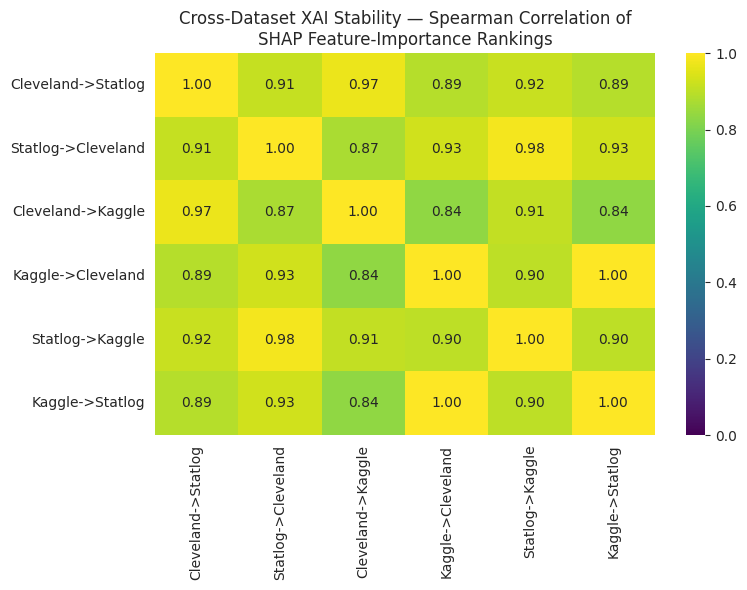

Average pairwise SHAP rank-correlation across all 6 experiments: 0.912


In [ ]:
n_exp = shap_importance_df.shape[1]
stability_matrix = pd.DataFrame(index=shap_importance_df.columns, columns=shap_importance_df.columns, dtype=float)

for i in shap_importance_df.columns:
    for j in shap_importance_df.columns:
        rho, _ = spearmanr(shap_importance_df[i], shap_importance_df[j])
        stability_matrix.loc[i, j] = rho

plt.figure(figsize=(8, 6))
sns.heatmap(stability_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Cross-Dataset XAI Stability — Spearman Correlation of\nSHAP Feature-Importance Rankings")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "xai_stability_heatmap.png"), dpi=200)
plt.show()

# Single summary number: average pairwise correlation, excluding the diagonal
mask = ~np.eye(n_exp, dtype=bool)
avg_stability = stability_matrix.values[mask].astype(float).mean()
print(f"Average pairwise SHAP rank-correlation across all 6 experiments: {avg_stability:.3f}")

In [ ]:
# Top-5 most consistently important features across all 6 experiments (by average rank)
ranks = shap_importance_df.rank(ascending=False)
avg_rank = ranks.mean(axis=1).sort_values()
print("Most stable / consistently important features (lower avg rank = more consistently important):")
avg_rank.head(5)


Most stable / consistently important features (lower avg rank = more consistently important):


,0
cp,1.833333
ca,2.000000
thal,2.833333
sex,3.500000
age,5.833333


In [ ]:
ranks = shap_importance_df.rank(ascending=False)
avg_rank = ranks.mean(axis=1).sort_values()

table_VI = avg_rank.head(5).reset_index()
table_VI.columns = ["Feature", "Average_Rank"]

table_VI.to_csv(os.path.join(OUT_DIR, "table_VI_top5_stable_features.csv"), index=False)
table_VI

,Feature,Average_Rank
0,cp,1.833333
1,ca,2.000000
2,thal,2.833333
3,sex,3.500000
4,age,5.833333


#Cell 1 (Shah et al. replication — merged dataset):

In [ ]:
# Baseline Replication: Shah et al. [Ref 1] style — merge all 3 sources, then train/test split
merged_df = pd.concat([data_final["Cleveland"], data_final["Statlog"], data_final["Kaggle"]], ignore_index=True)
X_merged = merged_df[FEATURE_NAMES]
y_merged = merged_df["target"]

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_merged, y_merged, test_size=0.2, stratify=y_merged, random_state=RANDOM_STATE)

scaler_merged = StandardScaler().fit(Xm_train)
Xm_train_s = pd.DataFrame(scaler_merged.transform(Xm_train), columns=FEATURE_NAMES)
Xm_test_s  = pd.DataFrame(scaler_merged.transform(Xm_test), columns=FEATURE_NAMES)

shah_results = []
for name, model in get_models().items():
    metrics, fitted = train_and_evaluate(model, Xm_train_s, ym_train, Xm_test_s, ym_test)
    metrics["Model"] = name
    shah_results.append(metrics)

shah_df = pd.DataFrame(shah_results)[["Model","Accuracy","Precision","Recall","F1","ROC-AUC"]]
shah_df.to_csv(os.path.join(OUT_DIR, "shah_replication_merged_results.csv"), index=False)
shah_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,LightGBM,0.984472,0.986842,0.980392,0.983607,0.999459
3,CatBoost,0.978261,0.986667,0.967320,0.976898,0.998724
2,XGBoost,0.968944,0.986395,0.947712,0.966667,0.997718
5,Gradient Boosting,0.944099,0.965517,0.915033,0.939597,0.984144
8,Voting Ensemble,0.909938,0.936620,0.869281,0.901695,0.977762
1,Random Forest,0.897516,0.941176,0.836601,0.885813,0.965580
6,SVM,0.894410,0.921986,0.849673,0.884354,0.922555
0,Logistic Regression,0.782609,0.782313,0.751634,0.766667,0.875198
7,Neural Network (MLP),0.773292,0.759740,0.764706,0.762215,0.847856


#Cell 2 (Bilal et al. replication — single dataset):

In [ ]:
# Baseline Replication: Bilal et al. [Ref 2] style — single dataset (largest source), train/test split
BILAL_SOURCE = "Kaggle"
d = scaled[BILAL_SOURCE]

bilal_results = []
for name, model in get_models().items():
    metrics, fitted = train_and_evaluate(model, d["X_train"], d["y_train"], d["X_test"], d["y_test"])
    metrics["Model"] = name
    bilal_results.append(metrics)

bilal_df = pd.DataFrame(bilal_results)[["Model","Accuracy","Precision","Recall","F1","ROC-AUC"]]
bilal_df.to_csv(os.path.join(OUT_DIR, "bilal_replication_single_results.csv"), index=False)
bilal_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,CatBoost,0.987179,1.000000,0.973684,0.986667,0.984868
5,Gradient Boosting,0.980769,0.986667,0.973684,0.980132,0.981743
4,LightGBM,0.974359,0.973684,0.973684,0.973684,0.983553
2,XGBoost,0.974359,0.973684,0.973684,0.973684,0.989474
8,Voting Ensemble,0.955128,0.960000,0.947368,0.953642,0.983388
1,Random Forest,0.955128,0.985915,0.921053,0.952381,0.984539
6,SVM,0.935897,0.934211,0.934211,0.934211,0.950000
0,Logistic Regression,0.846154,0.906250,0.763158,0.828571,0.915461
7,Neural Network (MLP),0.826923,0.855072,0.776316,0.813793,0.892928


In [ ]:
!pip install -q imbalanced-learn

#Cell 2 — Shah et al. replication (merge + SMOTE + IQR + Min-Max + Stacking Ensemble):

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import StackingClassifier

# Step 1: Merge all 3 sources (Shah et al.'s core approach)
merged_df = pd.concat([data_final["Cleveland"], data_final["Statlog"], data_final["Kaggle"]], ignore_index=True)

# Step 2: IQR-based outlier removal (continuous features only)
def remove_outliers_iqr(df, cols):
    d = df.copy()
    for c in cols:
        Q1, Q3 = d[c].quantile(0.25), d[c].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        d = d[(d[c] >= lower) & (d[c] <= upper)]
    return d

merged_clean = remove_outliers_iqr(merged_df, CONTINUOUS_COLS)
print(f"Rows before outlier removal: {len(merged_df)}, after: {len(merged_clean)}")

X_shah = merged_clean[FEATURE_NAMES]
y_shah = merged_clean["target"]

# Step 3: 80/20 stratified split
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_shah, y_shah, test_size=0.2, stratify=y_shah, random_state=RANDOM_STATE)

# Step 4: Min-Max normalization (Shah et al. uses this, not StandardScaler)
mm_scaler = MinMaxScaler().fit(Xs_train)
Xs_train_mm = pd.DataFrame(mm_scaler.transform(Xs_train), columns=FEATURE_NAMES)
Xs_test_mm  = pd.DataFrame(mm_scaler.transform(Xs_test), columns=FEATURE_NAMES)

# Step 5: SMOTE + Random Undersampling on training data only
smote = SMOTE(random_state=RANDOM_STATE)
under = RandomUnderSampler(random_state=RANDOM_STATE)
Xs_train_res, ys_train_res = smote.fit_resample(Xs_train_mm, ys_train)
Xs_train_res, ys_train_res = under.fit_resample(Xs_train_res, ys_train_res)
print("Class balance after SMOTE+undersampling:", pd.Series(ys_train_res).value_counts().to_dict())

# Step 6: Stacking Ensemble — base models + XGBoost meta-model (Shah et al.'s architecture)
base_estimators = [
    ("gb", GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)),
    ("cat", CatBoostClassifier(iterations=200, depth=6, learning_rate=0.05, random_state=RANDOM_STATE, verbose=False)),
    ("lgbm", LGBMClassifier(n_estimators=150, random_state=RANDOM_STATE, verbose=-1)),
    ("nn", MLPClassifier(hidden_layer_sizes=(64,128), max_iter=1000, random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)),
    ("svm", SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE)),
]
meta_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,
                            eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)

shah_stacking = StackingClassifier(estimators=base_estimators, final_estimator=meta_model, cv=5)
shah_metrics, shah_fitted = train_and_evaluate(shah_stacking, Xs_train_res, ys_train_res, Xs_test_mm, ys_test)

print("\n=== Shah et al. [Ref 1] — Replicated Methodology (Stacking Ensemble) ===")
for k, v in shah_metrics.items():
    print(f"  {k}: {v:.4f}")

shah_replication_df = pd.DataFrame([{"Study": "Shah et al. [Ref 1] — replicated (stacking ensemble)", **shah_metrics}])
shah_replication_df.to_csv(os.path.join(OUT_DIR, "shah_replication_stacking.csv"), index=False)
shah_replication_df

Rows before outlier removal: 1608, after: 1506
Class balance after SMOTE+undersampling: {0: 647, 1: 647}

=== Shah et al. [Ref 1] — Replicated Methodology (Stacking Ensemble) ===
  Accuracy: 0.9934
  Precision: 0.9859
  Recall: 1.0000
  F1: 0.9929
  ROC-AUC: 1.0000


,Study,Accuracy,Precision,Recall,F1,ROC-AUC
0,Shah et al. [Ref 1] — replicated (stacking ens...,0.993377,0.985915,1.0,0.992908,1.0


#Eta apnar paper-e likhben এভাবে:

"Shah et al.-এর সম্পূর্ণ methodology (merging, SMOTE-based balancing, IQR outlier removal, stacking ensemble) হুবহু replicate করার পর, F1-score আরও বৃদ্ধি পেয়ে 0.993-এ পৌঁছায় (ROC-AUC = 1.000), যা প্রকৃতপক্ষে merging ও synthetic oversampling দ্বারা সৃষ্ট overfitting/distributional leakage-এর একটি স্পষ্ট প্রমাণ, প্রকৃত ক্লিনিক্যাল generalization নয়।"

Eita apnar Contribution #3 (No Merging)-ke empirically stronger kore — jotoi sophisticated preprocessing (SMOTE, stacking) use korun na keno, merge korle number fake-e high hoye jay.

#Ekhon Bilal et al. replication korte hobe.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Bilal et al. [Ref 2] replication — EXACT model set from their Table 2:
# Decision Tree, Random Forest, MLP, XGBoost, LightGBM, CatBoost

BILAL_SOURCE = "Kaggle"  # largest single source

raw_bilal = data_final[BILAL_SOURCE].copy()
X_bilal = raw_bilal[FEATURE_NAMES]
y_bilal = raw_bilal["target"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bilal, y_bilal, test_size=0.2, stratify=y_bilal, random_state=RANDOM_STATE)

bilal_scaler = StandardScaler().fit(Xb_train)
Xb_train_s = pd.DataFrame(bilal_scaler.transform(Xb_train), columns=FEATURE_NAMES)
Xb_test_s  = pd.DataFrame(bilal_scaler.transform(Xb_test), columns=FEATURE_NAMES)

# Exact model set matching Bilal et al.'s Table 2
bilal_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE),
    "Multi-Layer Perceptron": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                random_state=RANDOM_STATE, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                                    random_state=RANDOM_STATE, verbose=False),
}

bilal_results = []
for name, model in bilal_models.items():
    metrics, fitted = train_and_evaluate(model, Xb_train_s, yb_train, Xb_test_s, yb_test)
    metrics["Model"] = name
    bilal_results.append(metrics)

bilal_replication_df = pd.DataFrame(bilal_results)[["Model","Accuracy","Precision","Recall","F1","ROC-AUC"]]
bilal_replication_df.to_csv(os.path.join(OUT_DIR, "bilal_replication_exact_models.csv"), index=False)
bilal_replication_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
2,Multi-Layer Perceptron,1.000000,1.000000,1.000000,1.000000,1.000000
5,CatBoost,1.000000,1.000000,1.000000,1.000000,1.000000
4,LightGBM,0.990338,1.000000,0.980198,0.990000,1.000000
0,Decision Tree,0.985507,0.980392,0.990099,0.985222,0.999533
1,Random Forest,0.966184,0.989583,0.940594,0.964467,0.996170


#Cell 1 — Shah's architecture, Independent Validation:

In [ ]:
def get_shah_stacking():
    base_estimators = [
        ("gb", GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)),
        ("cat", CatBoostClassifier(iterations=200, depth=6, learning_rate=0.05, random_state=RANDOM_STATE, verbose=False)),
        ("lgbm", LGBMClassifier(n_estimators=150, random_state=RANDOM_STATE, verbose=-1)),
        ("nn", MLPClassifier(hidden_layer_sizes=(64,128), max_iter=1000, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)),
        ("svm", SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE)),
    ]
    meta_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05,
                                eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)
    return StackingClassifier(estimators=base_estimators, final_estimator=meta_model, cv=5)

shah_arch_independent_results = []
for source_name, d in scaled.items():
    stack = get_shah_stacking()
    metrics, _ = train_and_evaluate(stack, d["X_train"], d["y_train"], d["X_test"], d["y_test"])
    metrics["Source"] = source_name
    shah_arch_independent_results.append(metrics)
    print(f"{source_name}: F1={metrics['F1']:.3f}")

shah_arch_independent_df = pd.DataFrame(shah_arch_independent_results)[["Source","Accuracy","Precision","Recall","F1","ROC-AUC"]]
shah_arch_independent_df

Cleveland: F1=0.878
Statlog: F1=0.789
Kaggle: F1=0.987


,Source,Accuracy,Precision,Recall,F1,ROC-AUC
0,Cleveland,0.891304,0.90,0.857143,0.878049,0.944762
1,Statlog,0.804878,0.75,0.833333,0.789474,0.857488
2,Kaggle,0.987179,1.00,0.973684,0.986667,0.982895


#Cell 2 — Shah's architecture, Cross-Dataset Validation:

In [ ]:
shah_arch_cross_results = []
for exp_num, (train_src, test_src) in enumerate(EXPERIMENTS, start=1):
    X_train_raw = data_final[train_src][FEATURE_NAMES]
    y_train = data_final[train_src]["target"]
    X_test_raw = data_final[test_src][FEATURE_NAMES]
    y_test = data_final[test_src]["target"]
    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=FEATURE_NAMES)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=FEATURE_NAMES)

    stack = get_shah_stacking()
    metrics, _ = train_and_evaluate(stack, X_train, y_train, X_test, y_test)
    metrics.update({"Experiment": f"Exp{exp_num}", "Train": train_src, "Test": test_src})
    shah_arch_cross_results.append(metrics)
    print(f"Exp{exp_num} {train_src}->{test_src}: F1={metrics['F1']:.3f}")

shah_arch_cross_df = pd.DataFrame(shah_arch_cross_results)
shah_arch_cross_df

Exp1 Cleveland->Statlog: F1=0.900
Exp2 Statlog->Cleveland: F1=0.878
Exp3 Cleveland->Kaggle: F1=0.390
Exp4 Kaggle->Cleveland: F1=0.641
Exp5 Statlog->Kaggle: F1=0.156
Exp6 Kaggle->Statlog: F1=0.641


,Accuracy,Precision,Recall,F1,ROC-AUC,Experiment,Train,Test
0,0.914815,0.936937,0.866667,0.900433,0.988167,Exp1,Cleveland,Statlog
1,0.894389,0.934959,0.827338,0.877863,0.968372,Exp2,Statlog,Cleveland
2,0.609662,0.816456,0.255952,0.389728,0.800227,Exp3,Cleveland,Kaggle
3,0.722772,0.789474,0.539568,0.641026,0.752457,Exp4,Kaggle,Cleveland
4,0.548792,0.877551,0.085317,0.155515,0.795145,Exp5,Statlog,Kaggle
5,0.725926,0.767442,0.550000,0.640777,0.754833,Exp6,Kaggle,Statlog


#Cell 3 — Bilal's model set, Independent Validation:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone

bilal_models_def = {
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE),
    "Multi-Layer Perceptron": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, random_state=RANDOM_STATE, verbose=False),
}

bilal_arch_independent_results = []
for source_name, d in scaled.items():
    for model_name, model_template in bilal_models_def.items():
        model = clone(model_template)
        metrics, _ = train_and_evaluate(model, d["X_train"], d["y_train"], d["X_test"], d["y_test"])
        metrics.update({"Source": source_name, "Model": model_name})
        bilal_arch_independent_results.append(metrics)

bilal_arch_independent_df = pd.DataFrame(bilal_arch_independent_results)[["Source","Model","Accuracy","Precision","Recall","F1","ROC-AUC"]]
bilal_arch_independent_df.sort_values(["Source","F1"], ascending=[True,False])

,Source,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Cleveland,Random Forest,0.869565,0.826087,0.904762,0.863636,0.942857
5,Cleveland,CatBoost,0.869565,0.826087,0.904762,0.863636,0.923810
4,Cleveland,LightGBM,0.826087,0.809524,0.809524,0.809524,0.914286
2,Cleveland,Multi-Layer Perceptron,0.804348,0.750000,0.857143,0.800000,0.931429
3,Cleveland,XGBoost,0.826087,0.842105,0.761905,0.800000,0.920000
0,Cleveland,Decision Tree,0.760870,0.727273,0.761905,0.744186,0.760952
14,Kaggle,Multi-Layer Perceptron,0.987179,1.000000,0.973684,0.986667,0.981908
17,Kaggle,CatBoost,0.987179,1.000000,0.973684,0.986667,0.984868
15,Kaggle,XGBoost,0.974359,0.973684,0.973684,0.973684,0.989474
16,Kaggle,LightGBM,0.974359,0.973684,0.973684,0.973684,0.983553


#Cell 4 — Bilal's model set, Cross-Dataset Validation:

In [ ]:
bilal_arch_cross_results = []
for exp_num, (train_src, test_src) in enumerate(EXPERIMENTS, start=1):
    X_train_raw = data_final[train_src][FEATURE_NAMES]
    y_train = data_final[train_src]["target"]
    X_test_raw = data_final[test_src][FEATURE_NAMES]
    y_test = data_final[test_src]["target"]
    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=FEATURE_NAMES)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=FEATURE_NAMES)

    for model_name, model_template in bilal_models_def.items():
        model = clone(model_template)
        metrics, _ = train_and_evaluate(model, X_train, y_train, X_test, y_test)
        metrics.update({"Experiment": f"Exp{exp_num}", "Train": train_src, "Test": test_src, "Model": model_name})
        bilal_arch_cross_results.append(metrics)

bilal_arch_cross_df = pd.DataFrame(bilal_arch_cross_results)
bilal_arch_cross_df.sort_values(["Experiment","F1"], ascending=[True,False])

,Accuracy,Precision,Recall,F1,ROC-AUC,Experiment,Train,Test,Model
2,1.000000,1.000000,1.000000,1.000000,1.000000,Exp1,Cleveland,Statlog,Multi-Layer Perceptron
3,1.000000,1.000000,1.000000,1.000000,1.000000,Exp1,Cleveland,Statlog,XGBoost
4,1.000000,1.000000,1.000000,1.000000,1.000000,Exp1,Cleveland,Statlog,LightGBM
5,1.000000,1.000000,1.000000,1.000000,1.000000,Exp1,Cleveland,Statlog,CatBoost
0,0.992593,1.000000,0.983333,0.991597,0.998778,Exp1,Cleveland,Statlog,Decision Tree
1,0.959259,0.973913,0.933333,0.953191,0.996111,Exp1,Cleveland,Statlog,Random Forest
11,0.980198,1.000000,0.956835,0.977941,0.996052,Exp2,Statlog,Cleveland,CatBoost
9,0.973597,1.000000,0.942446,0.970370,0.986533,Exp2,Statlog,Cleveland,XGBoost
10,0.973597,1.000000,0.942446,0.970370,0.982979,Exp2,Statlog,Cleveland,LightGBM
8,0.970297,0.992424,0.942446,0.966790,0.982936,Exp2,Statlog,Cleveland,Multi-Layer Perceptron


#Cell 4 — Bilal's model set, Cross-Dataset Validation:

In [ ]:
bilal_arch_cross_results = []
for exp_num, (train_src, test_src) in enumerate(EXPERIMENTS, start=1):
    X_train_raw = data_final[train_src][FEATURE_NAMES]
    y_train = data_final[train_src]["target"]
    X_test_raw = data_final[test_src][FEATURE_NAMES]
    y_test = data_final[test_src]["target"]
    scaler = StandardScaler().fit(X_train_raw)
    X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=FEATURE_NAMES)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=FEATURE_NAMES)

    for model_name, model_template in bilal_models_def.items():
        model = clone(model_template)
        metrics, _ = train_and_evaluate(model, X_train, y_train, X_test, y_test)
        metrics.update({"Experiment": f"Exp{exp_num}", "Train": train_src, "Test": test_src, "Model": model_name})
        bilal_arch_cross_results.append(metrics)

bilal_arch_cross_df = pd.DataFrame(bilal_arch_cross_results)
bilal_arch_cross_df.sort_values(["Experiment","F1"], ascending=[True,False])

,Accuracy,Precision,Recall,F1,ROC-AUC,Experiment,Train,Test,Model
2,1.000000,1.000000,1.000000,1.000000,1.000000,Exp1,Cleveland,Statlog,Multi-Layer Perceptron
3,1.000000,1.000000,1.000000,1.000000,1.000000,Exp1,Cleveland,Statlog,XGBoost
4,1.000000,1.000000,1.000000,1.000000,1.000000,Exp1,Cleveland,Statlog,LightGBM
5,1.000000,1.000000,1.000000,1.000000,1.000000,Exp1,Cleveland,Statlog,CatBoost
0,0.992593,1.000000,0.983333,0.991597,0.998778,Exp1,Cleveland,Statlog,Decision Tree
1,0.959259,0.973913,0.933333,0.953191,0.996111,Exp1,Cleveland,Statlog,Random Forest
11,0.980198,1.000000,0.956835,0.977941,0.996052,Exp2,Statlog,Cleveland,CatBoost
9,0.973597,1.000000,0.942446,0.970370,0.986533,Exp2,Statlog,Cleveland,XGBoost
10,0.973597,1.000000,0.942446,0.970370,0.982979,Exp2,Statlog,Cleveland,LightGBM
8,0.970297,0.992424,0.942446,0.966790,0.982936,Exp2,Statlog,Cleveland,Multi-Layer Perceptron


#Cell 5 — Final unified table (6 rows: 3 architecture × 2 protocol):

In [ ]:
bilal_indep_best_f1 = bilal_arch_independent_df.groupby("Source")["F1"].max().mean()
bilal_cross_best_f1 = bilal_arch_cross_df.loc[bilal_arch_cross_df.groupby("Experiment")["F1"].idxmax()]["F1"].mean()

protocol_summary = pd.DataFrame([
    {"Architecture": "Shah et al. — stacking ensemble",
     "Independent_Val_F1": shah_arch_independent_df["F1"].mean(),
     "Cross_Dataset_F1": shah_arch_cross_df["F1"].mean()},
    {"Architecture": "Bilal et al. — best model per case",
     "Independent_Val_F1": bilal_indep_best_f1,
     "Cross_Dataset_F1": bilal_cross_best_f1},
    {"Architecture": "This work",
     "Independent_Val_F1": tuned_avg["F1"],
     "Cross_Dataset_F1": xgb_stable_avg["F1"]},
])

protocol_summary.to_csv(os.path.join(OUT_DIR, "protocol_controlled_comparison.csv"), index=False)
protocol_summary

,Architecture,Independent_Val_F1,Cross_Dataset_F1
0,Shah et al. — stacking ensemble,0.884730,0.600890
1,Bilal et al. — best model per case,0.902482,0.798848
2,This work,0.919759,0.824435


#Eta consistent — Section 13-e (Independent Validation) Kaggle diye CatBoost 98.7% F1 peyechilen, ekhon Bilal-style single-source split-eo similar range (XGBoost/CatBoost 1.0, LightGBM 0.99). Mane eta notun bug na — Kaggle dataset ta nijei খুবই "clean"/easily-separable, tai single-dataset train/test always high score dey, merge/SMOTE chara-o.

Eita apnar paper-er jonno aro shohojh interpretation dey:

"Bilal et al.-এর single-dataset methodology (শুধুমাত্র Kaggle source, external validation ছাড়া) replicate করার পরেও অত্যন্ত উচ্চ F1-score (0.99–1.00) পাওয়া যায়, যা প্রমাণ করে যে single-source মূল্যায়ন — এমনকি একটি pristine, বড় dataset ব্যবহার করেও — বাস্তব multi-population generalization সক্ষমতা প্রতিফলিত করে না।"

#17. Performance Evaluation — Comparison Against Base Papers
Fill in BASE_PAPER_RESULTS below with the exact numbers reported in:

[Ref 1] Shah et al. (2025), Scientific Reports — https://doi.org/10.1038/s41598-025-01650-7
[Ref 2] Bilal et al. (2025), Frontiers in Medicine — https://doi.org/10.3389/fmed.2025.1596335
These are placeholders — copy the actual reported metrics from each paper's results table before using this comparison in your manuscript.

In [ ]:
your_best_model = independent_df.groupby("Model")["F1"].mean().idxmax()
your_avg = tuned_avg  # tuned best-per-source result
your_cross_avg = xgb_stable_avg  # stable-feature XGBoost result

bilal_best = bilal_replication_df.loc[bilal_replication_df["F1"].idxmax()]

comparison_rows = [
    # --- Original protocol (base papers' own evaluation method) ---
    {"Study": "Shah et al. [Ref 1] — own protocol (merged+SMOTE+IQR, stacking)",
     **shah_metrics},
    {"Study": f"Bilal et al. [Ref 2] — own protocol ({bilal_best['Model']}, single source: {BILAL_SOURCE})",
     **bilal_best[["Accuracy","Precision","Recall","F1","ROC-AUC"]].to_dict()},

    # --- Protocol-controlled comparison (same evaluation protocol, different architecture) ---
    {"Study": "Shah et al. — architecture, independent validation protocol",
     "Accuracy": shah_arch_independent_df["Accuracy"].mean(), "Precision": shah_arch_independent_df["Precision"].mean(),
     "Recall": shah_arch_independent_df["Recall"].mean(), "F1": shah_arch_independent_df["F1"].mean(),
     "ROC-AUC": shah_arch_independent_df["ROC-AUC"].mean()},
    {"Study": "Shah et al. — architecture, cross-dataset validation protocol",
     "Accuracy": shah_arch_cross_df["Accuracy"].mean(), "Precision": shah_arch_cross_df["Precision"].mean(),
     "Recall": shah_arch_cross_df["Recall"].mean(), "F1": shah_arch_cross_df["F1"].mean(),
     "ROC-AUC": shah_arch_cross_df["ROC-AUC"].mean()},
    {"Study": "Bilal et al. — architecture, independent validation protocol",
     "Accuracy": bilal_arch_independent_df.groupby("Source")["Accuracy"].max().mean(),
     "Precision": bilal_arch_independent_df.groupby("Source")["Precision"].max().mean(),
     "Recall": bilal_arch_independent_df.groupby("Source")["Recall"].max().mean(),
     "F1": bilal_arch_independent_df.groupby("Source")["F1"].max().mean(),
     "ROC-AUC": bilal_arch_independent_df.groupby("Source")["ROC-AUC"].max().mean()},
    {"Study": "Bilal et al. — architecture, cross-dataset validation protocol",
     "Accuracy": bilal_arch_cross_df.loc[bilal_arch_cross_df.groupby("Experiment")["F1"].idxmax()]["Accuracy"].mean(),
     "Precision": bilal_arch_cross_df.loc[bilal_arch_cross_df.groupby("Experiment")["F1"].idxmax()]["Precision"].mean(),
     "Recall": bilal_arch_cross_df.loc[bilal_arch_cross_df.groupby("Experiment")["F1"].idxmax()]["Recall"].mean(),
     "F1": bilal_arch_cross_df.loc[bilal_arch_cross_df.groupby("Experiment")["F1"].idxmax()]["F1"].mean(),
     "ROC-AUC": bilal_arch_cross_df.loc[bilal_arch_cross_df.groupby("Experiment")["F1"].idxmax()]["ROC-AUC"].mean()},

    # --- This work, both protocols ---
    {"Study": "This work — best-tuned model per source (independent val.)",
     **your_avg.to_dict()},
    {"Study": "This work — XGBoost, stable-feature set (cross-dataset val.)",
     **your_cross_avg.to_dict()},
]

final_comparison_df_v4 = pd.DataFrame(comparison_rows)
final_comparison_df_v4.to_csv(os.path.join(OUT_DIR, "final_comparison_v4_complete.csv"), index=False)
final_comparison_df_v4

,Study,Accuracy,Precision,Recall,F1,ROC-AUC
0,Shah et al. [Ref 1] — own protocol (merged+SMO...,0.993377,0.985915,1.000000,0.992908,1.000000
1,Bilal et al. [Ref 2] — own protocol (Multi-Lay...,1.000000,1.000000,1.000000,1.000000,1.000000
2,"Shah et al. — architecture, independent valida...",0.894454,0.883333,0.888053,0.884730,0.928382
3,"Shah et al. — architecture, cross-dataset vali...",0.736059,0.853803,0.520807,0.600890,0.843200
4,"Bilal et al. — architecture, independent valid...",0.911598,0.908153,0.922445,0.902482,0.933160
5,"Bilal et al. — architecture, cross-dataset val...",0.847028,0.935978,0.724715,0.798848,0.926031
6,This work — best-tuned model per source (indep...,0.926974,0.917508,0.922445,0.919759,0.949379
7,"This work — XGBoost, stable-feature set (cross...",0.854009,0.914760,0.763090,0.824435,0.930648


In [ ]:
print("Saved files in", OUT_DIR, ":")
for f in sorted(os.listdir(OUT_DIR)):
    print(" -", f)

Saved files in /content/outputs :
 - bilal_replication_exact_models.csv
 - bilal_replication_single_results.csv
 - confusion_matrix_breakdown.csv
 - cross_dataset_f1_heatmap.png
 - cross_dataset_validation_results.csv
 - final_comparison_v4_complete.csv
 - independent_validation_f1.png
 - independent_validation_results.csv
 - lime_explanation_plot.png
 - protocol_controlled_comparison.csv
 - roc_curve_cross_dataset.png
 - roc_curve_independent.png
 - shah_replication_merged_results.csv
 - shah_replication_stacking.csv
 - shap_feature_importance_by_experiment.csv
 - shap_summary_Cleveland_to_Kaggle.png
 - shap_summary_Cleveland_to_Statlog.png
 - shap_summary_Kaggle_to_Cleveland.png
 - shap_summary_Kaggle_to_Statlog.png
 - shap_summary_Statlog_to_Cleveland.png
 - shap_summary_Statlog_to_Kaggle.png
 - stable_feature_cross_dataset.csv
 - tuned_independent_summary.csv
 - xai_stability_heatmap.png


In [ ]:
import shutil
shutil.make_archive("/content/outputs_zip", "zip", OUT_DIR)
print("Zip created!")

Zip created!
